# EDA - GCP Taxi Fare Prediction

In [80]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2

# system
import os
from pathlib import Path
import sys
sys.path.append(str(Path().resolve().parents[2]))  # workaround to resolve my helper module above

# dataframe
import polars as pl
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point

# modules
from modules.plotting import *
from modules.polars_helpers import *

# stats
from scipy.stats import pearsonr

# plotting
from matplotlib.ticker import FuncFormatter

parent_dir = Path.cwd().parent

DATA_PATH = str(parent_dir / "data/")
print(DATA_PATH)

RANDOM_SEED = 42

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
/Users/luiscruz/Desktop/kaggle_challenges/regression/gcp-taxi-fare-prediction/data


In [2]:
if not os.path.exists(DATA_PATH + "/train.parquet"):
    train_csv = pl.read_csv(DATA_PATH + "/train.csv")
    train_csv.write_parquet(DATA_PATH + "/train.parquet")
train = pl.scan_parquet(DATA_PATH + "/train.parquet")
train.collect_schema()

Schema([('key', String),
        ('fare_amount', Float64),
        ('pickup_datetime', String),
        ('pickup_longitude', Float64),
        ('pickup_latitude', Float64),
        ('dropoff_longitude', Float64),
        ('dropoff_latitude', Float64),
        ('passenger_count', Int64)])

In [3]:
train.describe()

statistic,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
str,str,f64,str,f64,f64,f64,f64,f64
"""count""","""55423856""",5.5423856e7,"""55423856""",5.5423856e7,5.5423856e7,5.542348e7,5.542348e7,5.5423856e7
"""null_count""","""0""",0.0,"""0""",0.0,0.0,376.0,376.0,0.0
"""mean""",null,11.345046,null,-72.509684,39.919792,-72.51121,39.920681,1.68538
"""std""",null,20.710832,null,12.848883,9.642353,12.782197,9.633346,1.327664
"""min""","""2009-01-01 00:00:27.0000001""",-300.0,"""2009-01-01 00:00:27 UTC""",-3442.059565,-3492.263768,-3442.024565,-3547.886698,0.0
"""25%""",null,6.0,null,-73.992071,40.734932,-73.9914,40.734032,1.0
"""50%""",null,8.5,null,-73.981803,40.752652,-73.98015,40.753157,1.0
"""75%""",null,12.5,null,-73.967078,40.767132,-73.963674,40.7681,2.0
"""max""","""2015-06-30 23:59:54.0000003""",93963.36,"""2015-06-30 23:59:54 UTC""",3457.625683,3408.789565,3457.62235,3537.132528,208.0


In [4]:
train

Data contains:
- fare amount
- pickup datetime
- pickup latitude
- pickup longitude
- dropoff latitude
- dropoff longitude
- passenger count

Some ideas:
- calculate manhattan distance using geo points OK
- visualize some using geopandas OK
- break datetime into year, month, hour OK
- get day of week OK
- get NYC pickup and dropoff borough OK
- shap values for high explainability
- use features up until the end of this notebook and create route feature and embed it before NN

In [5]:
train.null_count().collect()

key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,376,376,0


In [6]:
train = train.drop_nulls()
train.null_count().collect()

key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0


## Fare Amount

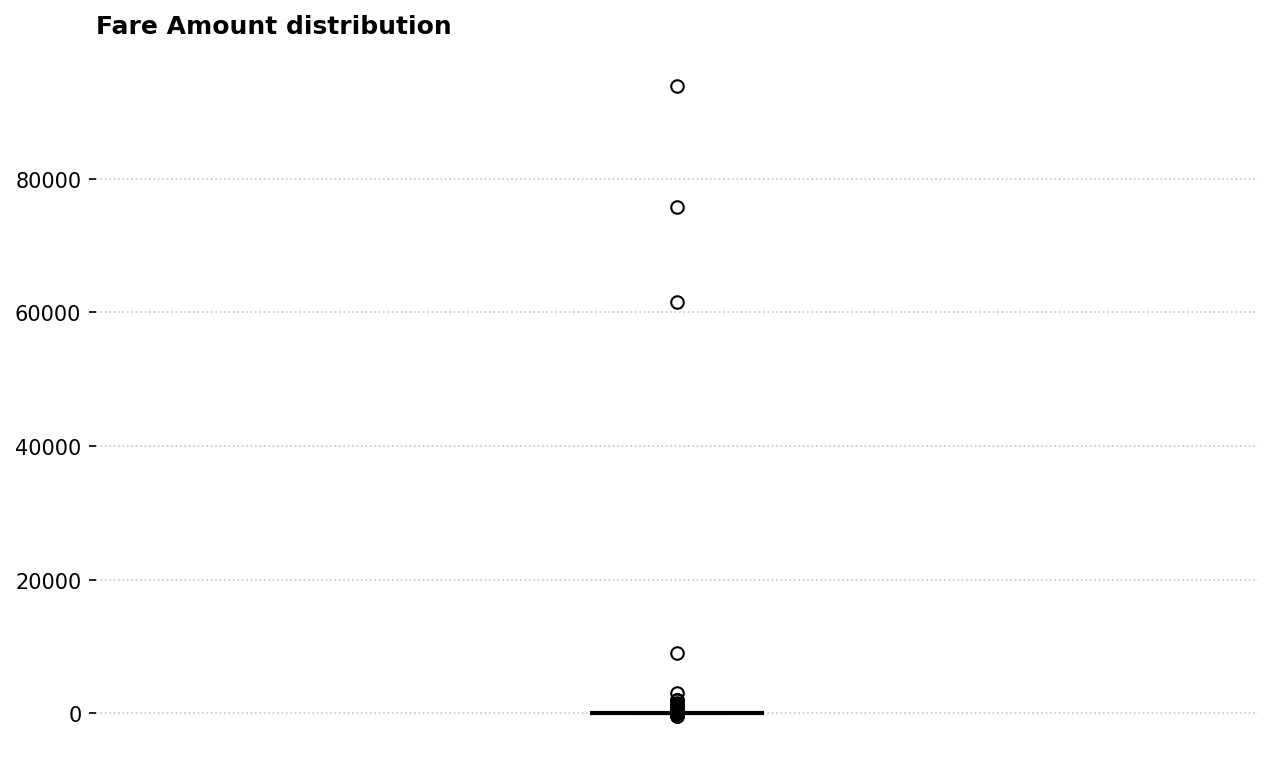

In [7]:
boxplot(train.select("fare_amount").collect(), "Fare Amount distribution")

We can see this data contains several outliers reaching the 5 digit mark. The feasibility of this happening is not much so that we should keep these targets in order to improve generalization

## Passenger Count and Fare Amount

In [8]:
passenger_fare = train.select(["passenger_count", "fare_amount"]).collect()

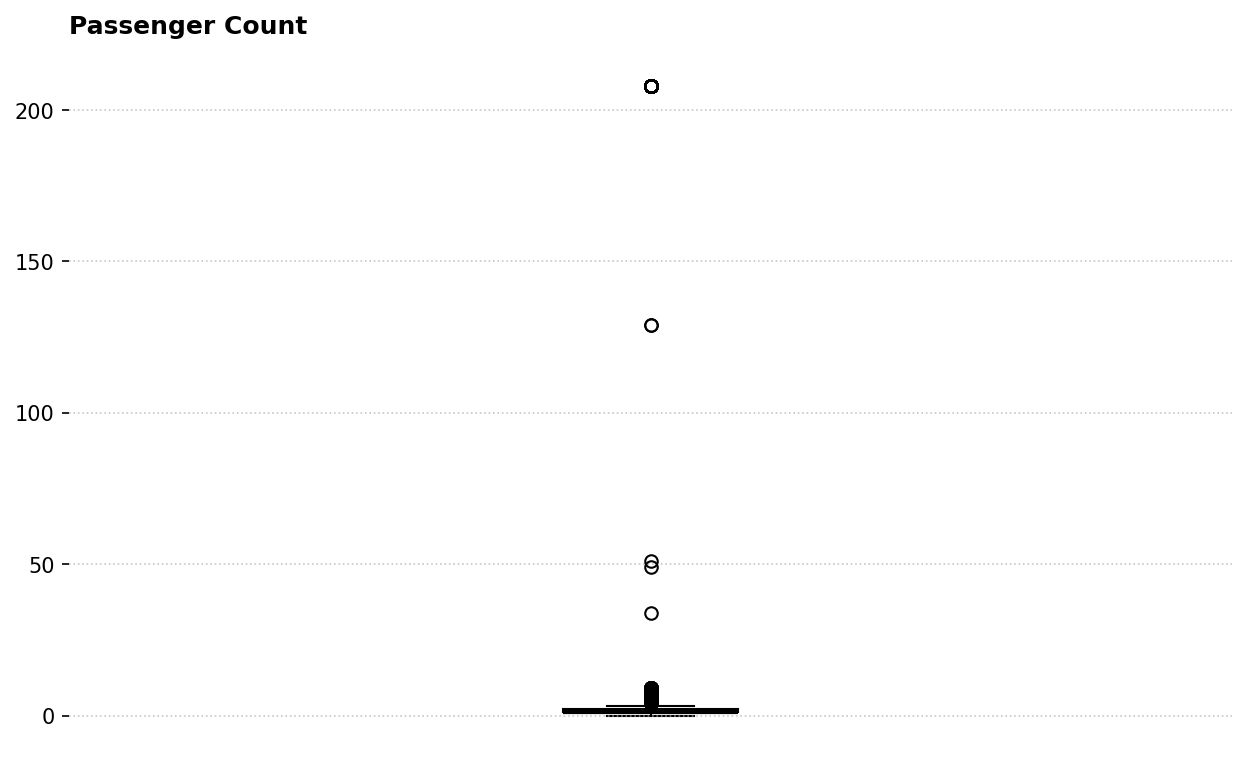

In [9]:
boxplot(passenger_fare["passenger_count"], "Passenger Count")

The largest cab in NYC holds up to 5 passengers: the minivan (https://en.wikipedia.org/wiki/Taxis_of_New_York_City#:~:text=A%20maximum%20of%20four%20passengers,or%20Newark%20Liberty%20International%20Airport.). Previously to 2024, however, if a maximum had been reached, one child under 7 could sit on an adult's lap on the ride. Since this data ranges from 2009 to 2015, that did in fact hold true.

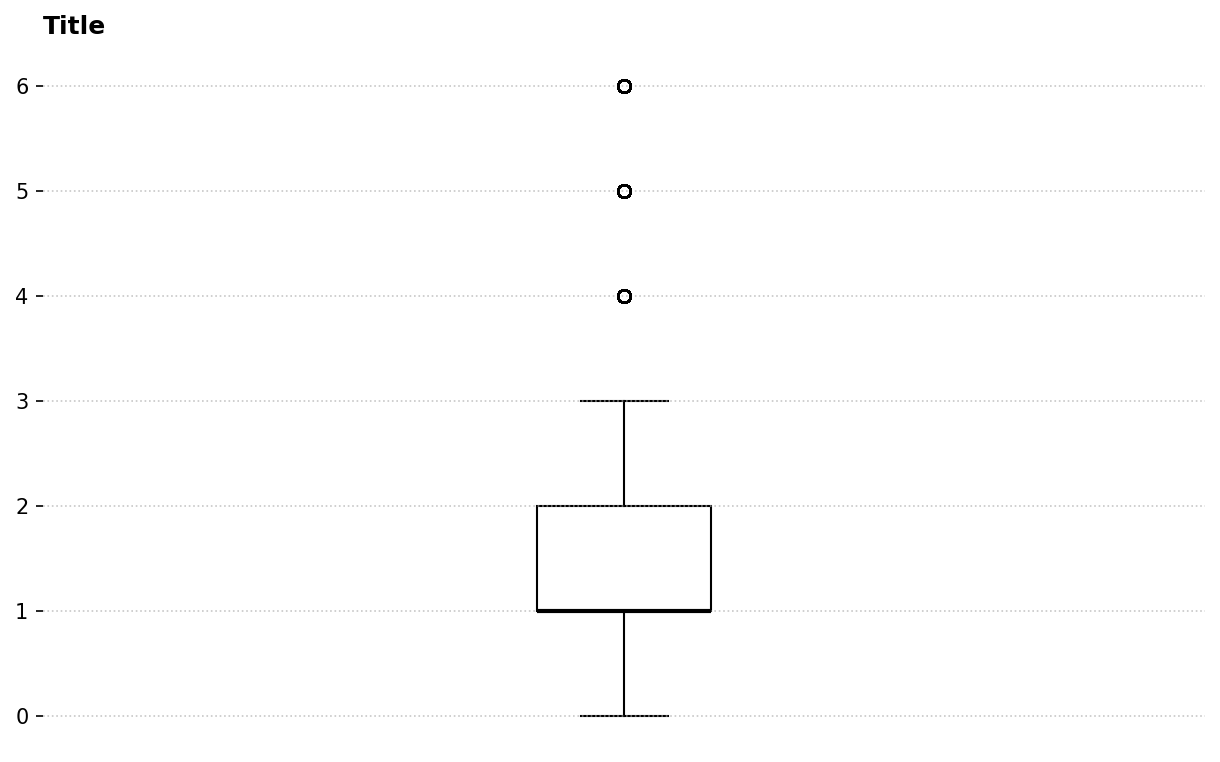

In [10]:
passenger_fare = passenger_fare.filter(pl.col("passenger_count") <= 6)
boxplot(passenger_fare["passenger_count"])

In [11]:
passenger_fare["passenger_count"].describe()

statistic,value
str,f64
"""count""",5.5423364e7
"""null_count""",0.0
"""mean""",1.685141
"""std""",1.308744
"""min""",0.0
"""25%""",1.0
"""50%""",1.0
"""75%""",2.0
"""max""",6.0


In [12]:
passenger_fare.filter(pl.col("passenger_count") == 0).describe()

statistic,passenger_count,fare_amount
str,f64,f64
"""count""",195040.0,195040.0
"""null_count""",0.0,0.0
"""mean""",0.0,8.999295
"""std""",0.0,6.481742
"""min""",0.0,-12.5
"""25%""",0.0,5.3
"""50%""",0.0,7.3
"""75%""",0.0,10.5
"""max""",0.0,259.0


I fear how common are taxi runs with 0 passengers. Even though it's possible, I argue it isn't the regular case. Since there are only 195_000 of such entries, I feel safe to remove them

In [13]:
passenger_fare = passenger_fare.filter(pl.col("passenger_count") > 0)
passenger_fare.describe()

statistic,passenger_count,fare_amount
str,f64,f64
"""count""",5.5228324e7,5.5228324e7
"""null_count""",0.0,0.0
"""mean""",1.691092,11.353273
"""std""",1.30721,20.743338
"""min""",1.0,-300.0
"""25%""",1.0,6.0
"""50%""",1.0,8.5
"""75%""",2.0,12.5
"""max""",6.0,93963.36


Coming back to the matter of fare amount, research indicates that fares may get close to $200 in some cases, for example, a trip from JFK Airport to Newark Airport, which is subject to a fare range of $157 - $177 (https://www.jfkairport.com/to-from-airport/taxi-car-and-van-service), so we may safely filter out values above $200 to include these cases. Also, the minimum fare of the taxi ride was of $2.50 at the time range of this dataset, only being changed in 2022 (https://rules.cityofnewyork.us/rule/taximeter-rate-of-fare-and-various-surcharges/#:~:text=%2D%20The%20initial%20unit%20charge%20is,increased%20from%20$1.00%20to%20$2.50.)

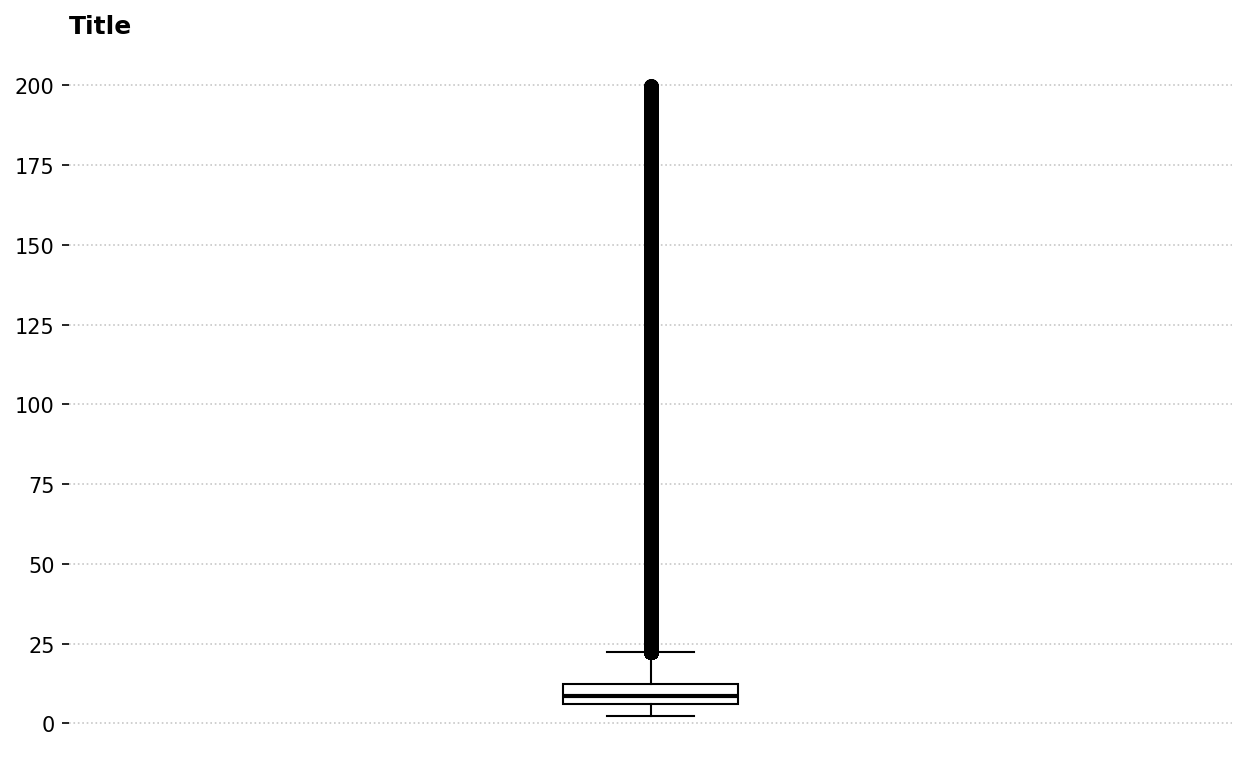

In [14]:
passenger_fare = passenger_fare.filter((pl.col("fare_amount") >= 2.5) & (pl.col("fare_amount") < 200))
boxplot(passenger_fare["fare_amount"])

In [15]:
passenger_fare.describe()

statistic,passenger_count,fare_amount
str,f64,f64
"""count""",5.5221662e7,5.5221662e7
"""null_count""",0.0,0.0
"""mean""",1.691108,11.341187
"""std""",1.307228,9.669569
"""min""",1.0,2.5
"""25%""",1.0,6.0
"""50%""",1.0,8.5
"""75%""",2.0,12.5
"""max""",6.0,199.99


We may now try to stablish a relationship between the fare amount and the passenger count

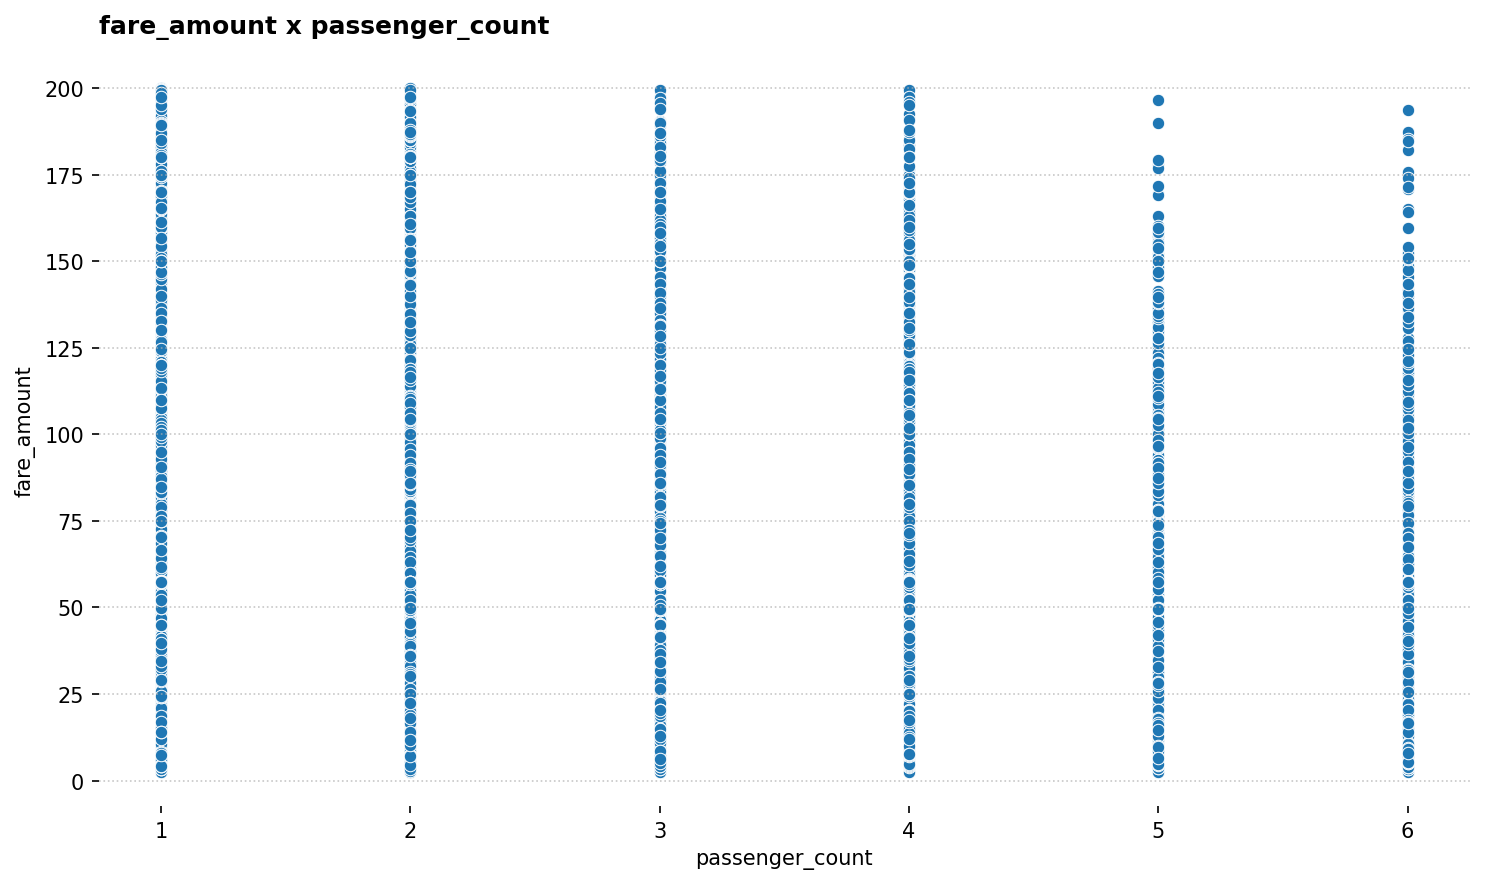

In [16]:
scatter_plot(passenger_fare, "passenger_count", "fare_amount", "fare_amount x passenger_count")

In [17]:
pearsonr(passenger_fare["passenger_count"], passenger_fare["fare_amount"])

PearsonRResult(statistic=0.012702966503900123, pvalue=0.0)

It's not possible to state that the passenger count has a linear correlation with the fare amount. Maybe interacting with another variable, but not on its own

## Lat and Long

Let's begin this section by applying the operations we previously did to the whole dataset for consistency

In [18]:
train = train.filter(
    (pl.col("fare_amount") >= 2.5) & (pl.col("fare_amount") < 200)
).filter(
    (pl.col("passenger_count") <= 6) & (pl.col("passenger_count") > 0)
)

train.describe()

statistic,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
str,str,f64,str,f64,f64,f64,f64,f64
"""count""","""55221662""",5.5221662e7,"""55221662""",5.5221662e7,5.5221662e7,5.5221662e7,5.5221662e7,5.5221662e7
"""null_count""","""0""",0.0,"""0""",0.0,0.0,0.0,0.0,0.0
"""mean""",null,11.341187,null,-72.510034,39.919962,-72.511932,39.92102,1.691108
"""std""",null,9.669569,null,12.856192,9.645472,12.785346,9.64395,1.307228
"""min""","""2009-01-01 00:00:27.0000001""",2.5,"""2009-01-01 00:00:27 UTC""",-3442.059565,-3492.263768,-3442.024565,-3547.886698,1.0
"""25%""",null,6.0,null,-73.992072,40.734928,-73.9914,40.73403,1.0
"""50%""",null,8.5,null,-73.981805,40.75265,-73.98015,40.753155,1.0
"""75%""",null,12.5,null,-73.96708,40.76713,-73.963672,40.768098,2.0
"""max""","""2015-06-30 23:59:54.0000003""",199.99,"""2015-06-30 23:59:54 UTC""",3457.625683,3408.789565,3457.62235,3537.132528,6.0


The maximum latitude in New York City is around 40° 51' N (40.85 degrees) and the minimum latitude is around 40° 41' N (40.68 degrees). The maximum longitude is around 73° 50' W (-73.83 degrees), and the minimum longitude is around 74° 15' W (-74.25 degrees). We must then restrict the observations to this range. There are observations out of this range that lie near either -3000 or +3000, which are invalid, since Latitudes range from 0 to 90, and longitudes from 0 to 180

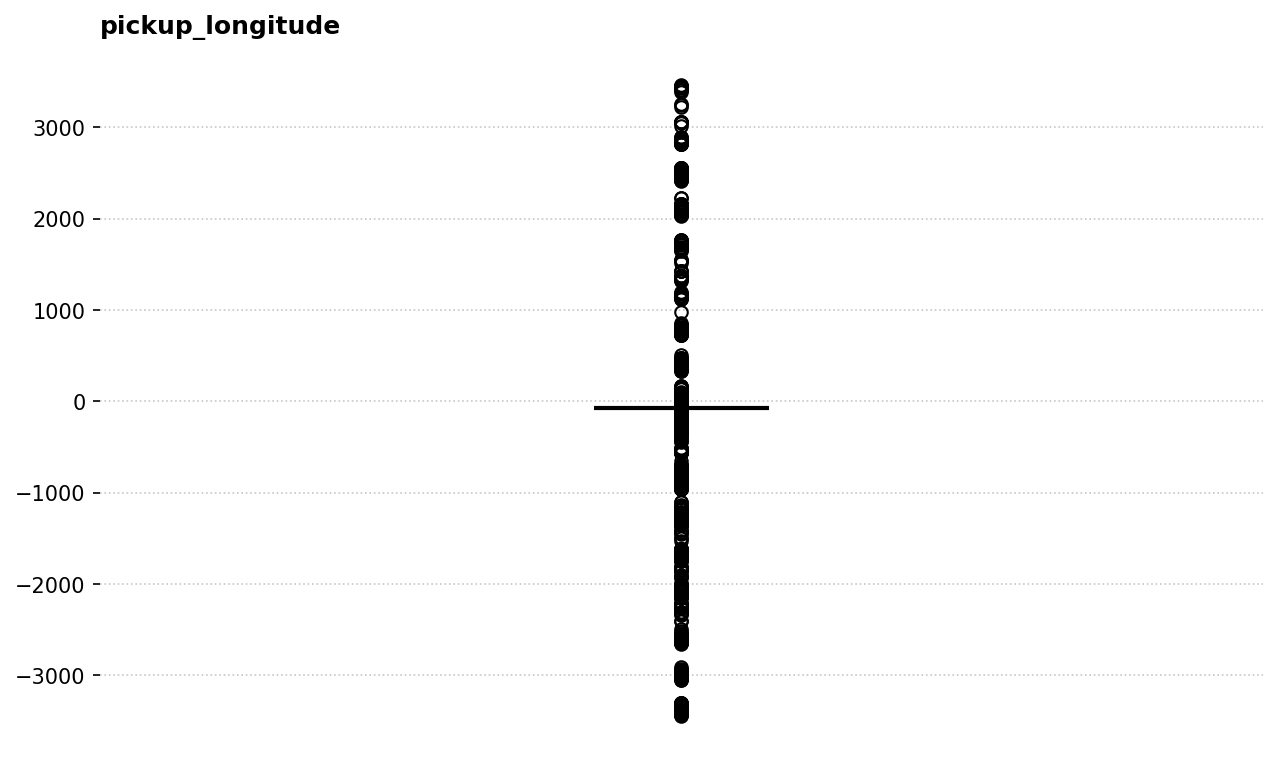

In [19]:
boxplot(train.select("pickup_longitude").collect(), "pickup_longitude")

It seems there are several mismeasurements on pickup longitude that can also be seen on the other coordinate's data summary, ranging way out of the valid measurements for NYC. Let's restrict all observations to the known boudaries of NYC, since using boundaries outside of NYC would be conceptually wrong

In [20]:
MAX_LAT = 40.85
MIN_LAT = 40.68

MAX_LONG = -73.83
MIN_LONG = -74.25

train = train \
    .filter((pl.col("pickup_latitude") <= MAX_LAT) & (pl.col("pickup_latitude") >= MIN_LAT)) \
    .filter((pl.col("dropoff_latitude") <= MAX_LAT) & (pl.col("dropoff_latitude") >= MIN_LAT)) \
    .filter((pl.col("pickup_longitude") <= MAX_LONG) & (pl.col("pickup_longitude") >= MIN_LONG)) \
    .filter((pl.col("dropoff_longitude") <= MAX_LONG) & (pl.col("dropoff_longitude") >= MIN_LONG)) 

In [21]:
train.describe()

statistic,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
str,str,f64,str,f64,f64,f64,f64,f64
"""count""","""51439929""",5.1439929e7,"""51439929""",5.1439929e7,5.1439929e7,5.1439929e7,5.1439929e7,5.1439929e7
"""null_count""","""0""",0.0,"""0""",0.0,0.0,0.0,0.0,0.0
"""mean""",null,10.16987,null,-73.978816,40.753039,-73.977383,40.753365,1.689366
"""std""",null,7.155324,null,0.023849,0.022414,0.026063,0.024919,1.306355
"""min""","""2009-01-01 00:00:46.0000002""",2.5,"""2009-01-01 00:00:46 UTC""",-74.25,40.68,-74.25,40.68,1.0
"""25%""",null,6.0,null,-73.992443,40.738187,-73.9918,40.737795,1.0
"""50%""",null,8.1,null,-73.982286,40.754317,-73.981077,40.754717,1.0
"""75%""",null,12.0,null,-73.969443,40.767958,-73.967016,40.768609,2.0
"""max""","""2015-06-30 23:59:54.0000003""",199.7,"""2015-06-30 23:59:54 UTC""",-73.83,40.85,-73.83,40.85,6.0


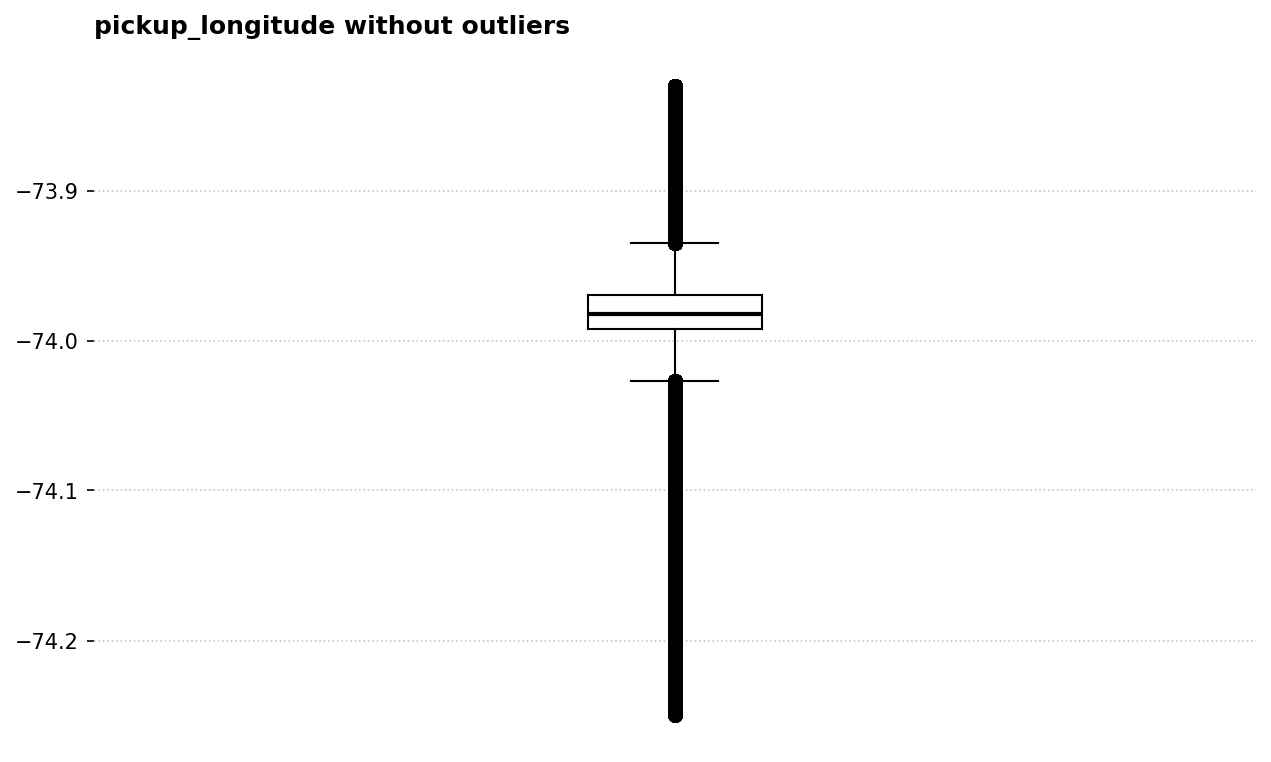

In [22]:
boxplot(train.select("pickup_longitude").collect(), "pickup_longitude without outliers")

## Manhattan Distance

We can calculate a proxy for the distance between pickup and dropoff by computing the Manhattan Distance on pickup and dropoff points, which may lead to a clue on the correlation between distance and fare. It's important to keep in mind that this distance is the sum of absolute differences in coordinates, so it will be the sum of the differences in vertical and horizontal axis, on the degree's scale

In [23]:
train = train.with_columns(
    (
        (pl.col("pickup_latitude") - pl.col("dropoff_latitude")).abs()
        +
        (pl.col("pickup_longitude") - pl.col("dropoff_longitude")).abs()
    ).alias("ride_distance")
)

In [24]:
train.head(3).collect()

key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,ride_distance
str,f64,str,f64,f64,f64,f64,i64,f64
"""2009-06-15 17:26:21.0000001""",4.5,"""2009-06-15 17:26:21 UTC""",-73.844311,40.721319,-73.84161,40.712278,1,0.011742
"""2010-01-05 16:52:16.0000002""",16.9,"""2010-01-05 16:52:16 UTC""",-74.016048,40.711303,-73.979268,40.782004,1,0.107481
"""2011-08-18 00:35:00.00000049""",5.7,"""2011-08-18 00:35:00 UTC""",-73.982738,40.76127,-73.991242,40.750562,2,0.019212


In [25]:
train.describe()

statistic,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,ride_distance
str,str,f64,str,f64,f64,f64,f64,f64,f64
"""count""","""51439929""",5.1439929e7,"""51439929""",5.1439929e7,5.1439929e7,5.1439929e7,5.1439929e7,5.1439929e7,5.1439929e7
"""null_count""","""0""",0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,10.16987,null,-73.978816,40.753039,-73.977383,40.753365,1.689366,0.037097
"""std""",null,7.155324,null,0.023849,0.022414,0.026063,0.024919,1.306355,0.032486
"""min""","""2009-01-01 00:00:46.0000002""",2.5,"""2009-01-01 00:00:46 UTC""",-74.25,40.68,-74.25,40.68,1.0,0.0
"""25%""",null,6.0,null,-73.992443,40.738187,-73.9918,40.737795,1.0,0.01602
"""50%""",null,8.1,null,-73.982286,40.754317,-73.981077,40.754717,1.0,0.027026
"""75%""",null,12.0,null,-73.969443,40.767958,-73.967016,40.768609,2.0,0.046615
"""max""","""2015-06-30 23:59:54.0000003""",199.7,"""2015-06-30 23:59:54 UTC""",-73.83,40.85,-73.83,40.85,6.0,0.48658


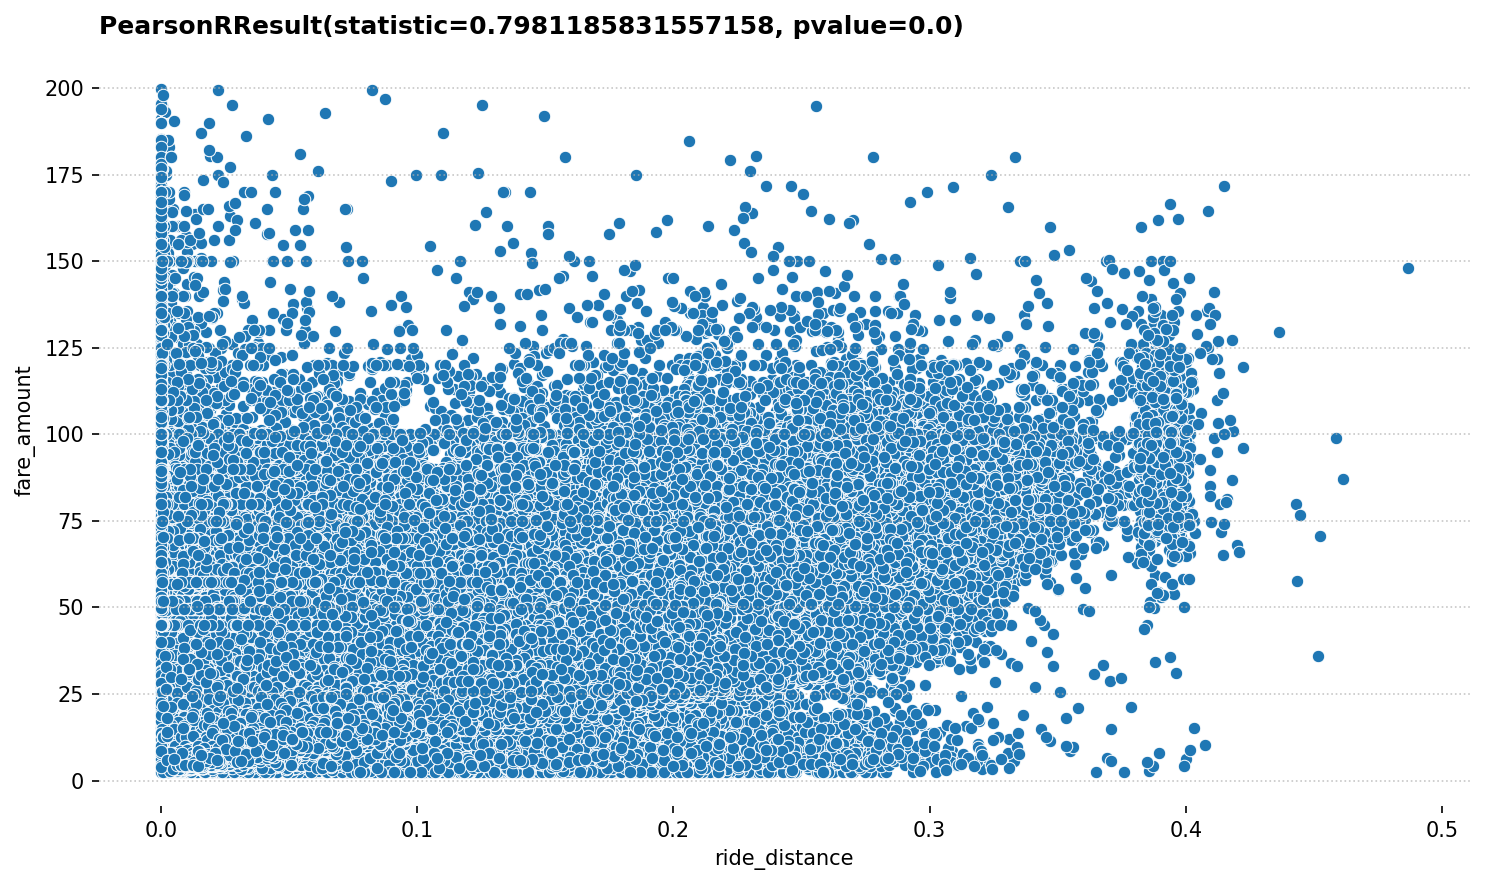

In [26]:
ride_and_distance = train.select(["ride_distance", "fare_amount"]).collect()

lin_corr_fare_distance = pearsonr(ride_and_distance["fare_amount"], ride_and_distance["ride_distance"])

scatter_plot(ride_and_distance, "ride_distance", "fare_amount", f"{lin_corr_fare_distance}")

In [27]:
ride_and_distance = ride_and_distance.filter(
    pl.col("ride_distance") > 0
)

pearsonr(ride_and_distance["fare_amount"], ride_and_distance["ride_distance"])

PearsonRResult(statistic=0.8136963679497274, pvalue=0.0)

In [28]:
ride_and_distance.describe()

statistic,ride_distance,fare_amount
str,f64,f64
"""count""",5.0931206e7,5.0931206e7
"""null_count""",0.0,0.0
"""mean""",0.037467,10.171706
"""std""",0.032435,7.097084
"""min""",1.0000e-6,2.5
"""25%""",0.016304,6.0
"""50%""",0.027288,8.1
"""75%""",0.046929,12.0
"""max""",0.48658,199.5


There seems to be a strong correlation between the ride distance and its fare, this may be a good explanatory variable for this target

## Date

In [29]:
train.describe()

statistic,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,ride_distance
str,str,f64,str,f64,f64,f64,f64,f64,f64
"""count""","""51439929""",5.1439929e7,"""51439929""",5.1439929e7,5.1439929e7,5.1439929e7,5.1439929e7,5.1439929e7,5.1439929e7
"""null_count""","""0""",0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",null,10.16987,null,-73.978816,40.753039,-73.977383,40.753365,1.689366,0.037097
"""std""",null,7.155324,null,0.023849,0.022414,0.026063,0.024919,1.306355,0.032486
"""min""","""2009-01-01 00:00:46.0000002""",2.5,"""2009-01-01 00:00:46 UTC""",-74.25,40.68,-74.25,40.68,1.0,0.0
"""25%""",null,6.0,null,-73.992443,40.738187,-73.9918,40.737795,1.0,0.01602
"""50%""",null,8.1,null,-73.982286,40.754317,-73.981077,40.754717,1.0,0.027026
"""75%""",null,12.0,null,-73.969443,40.767958,-73.967016,40.768609,2.0,0.046615
"""max""","""2015-06-30 23:59:54.0000003""",199.7,"""2015-06-30 23:59:54 UTC""",-73.83,40.85,-73.83,40.85,6.0,0.48658


In [30]:
train = train.with_columns([
    pl.col("pickup_datetime")
    .str.strip_chars()
    .str.strip_suffix(" UTC")
    .str.strptime(pl.Datetime, "%Y-%m-%d %H:%M:%S")
    .alias("pickup_datetime_parsed")
])

train = train.with_columns([
    pl.col("pickup_datetime_parsed").dt.year().alias("year"),
    pl.col("pickup_datetime_parsed").dt.month().alias("month"),
    pl.col("pickup_datetime_parsed").dt.hour().alias("hour"),
    pl.col("pickup_datetime_parsed").dt.weekday().alias("day_of_week") # monday = 1 and sunday = 7
])

train

### Month

In [31]:
wide_by_month, months = pivot_table_on_column(train.select(["month", "fare_amount"]).collect(), "month", "fare_amount")

In [32]:
wide_by_month

1,2,3,4,5,6,7,8,9,10,11,12
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
16.9,12.5,5.3,7.7,9.3,4.5,7.0,5.7,8.9,10.9,7.5,9.0
12.1,11.5,4.5,5.3,34.67,7.3,5.3,4.5,10.5,5.5,4.1,4.0
16.5,5.5,9.8,7.7,7.0,4.5,5.3,4.5,5.7,7.5,9.0,4.9
31.9,7.0,8.1,4.5,5.0,12.1,3.3,6.9,7.5,12.0,17.5,6.1
58.0,7.7,5.3,16.5,6.9,4.5,13.7,6.9,19.0,7.5,7.3,3.3
…,…,…,…,…,…,…,…,…,…,…,…
null,null,8.1,null,null,null,null,null,null,null,null,null
null,null,12.0,null,null,null,null,null,null,null,null,null
null,null,4.5,null,null,null,null,null,null,null,null,null


In [33]:
months

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

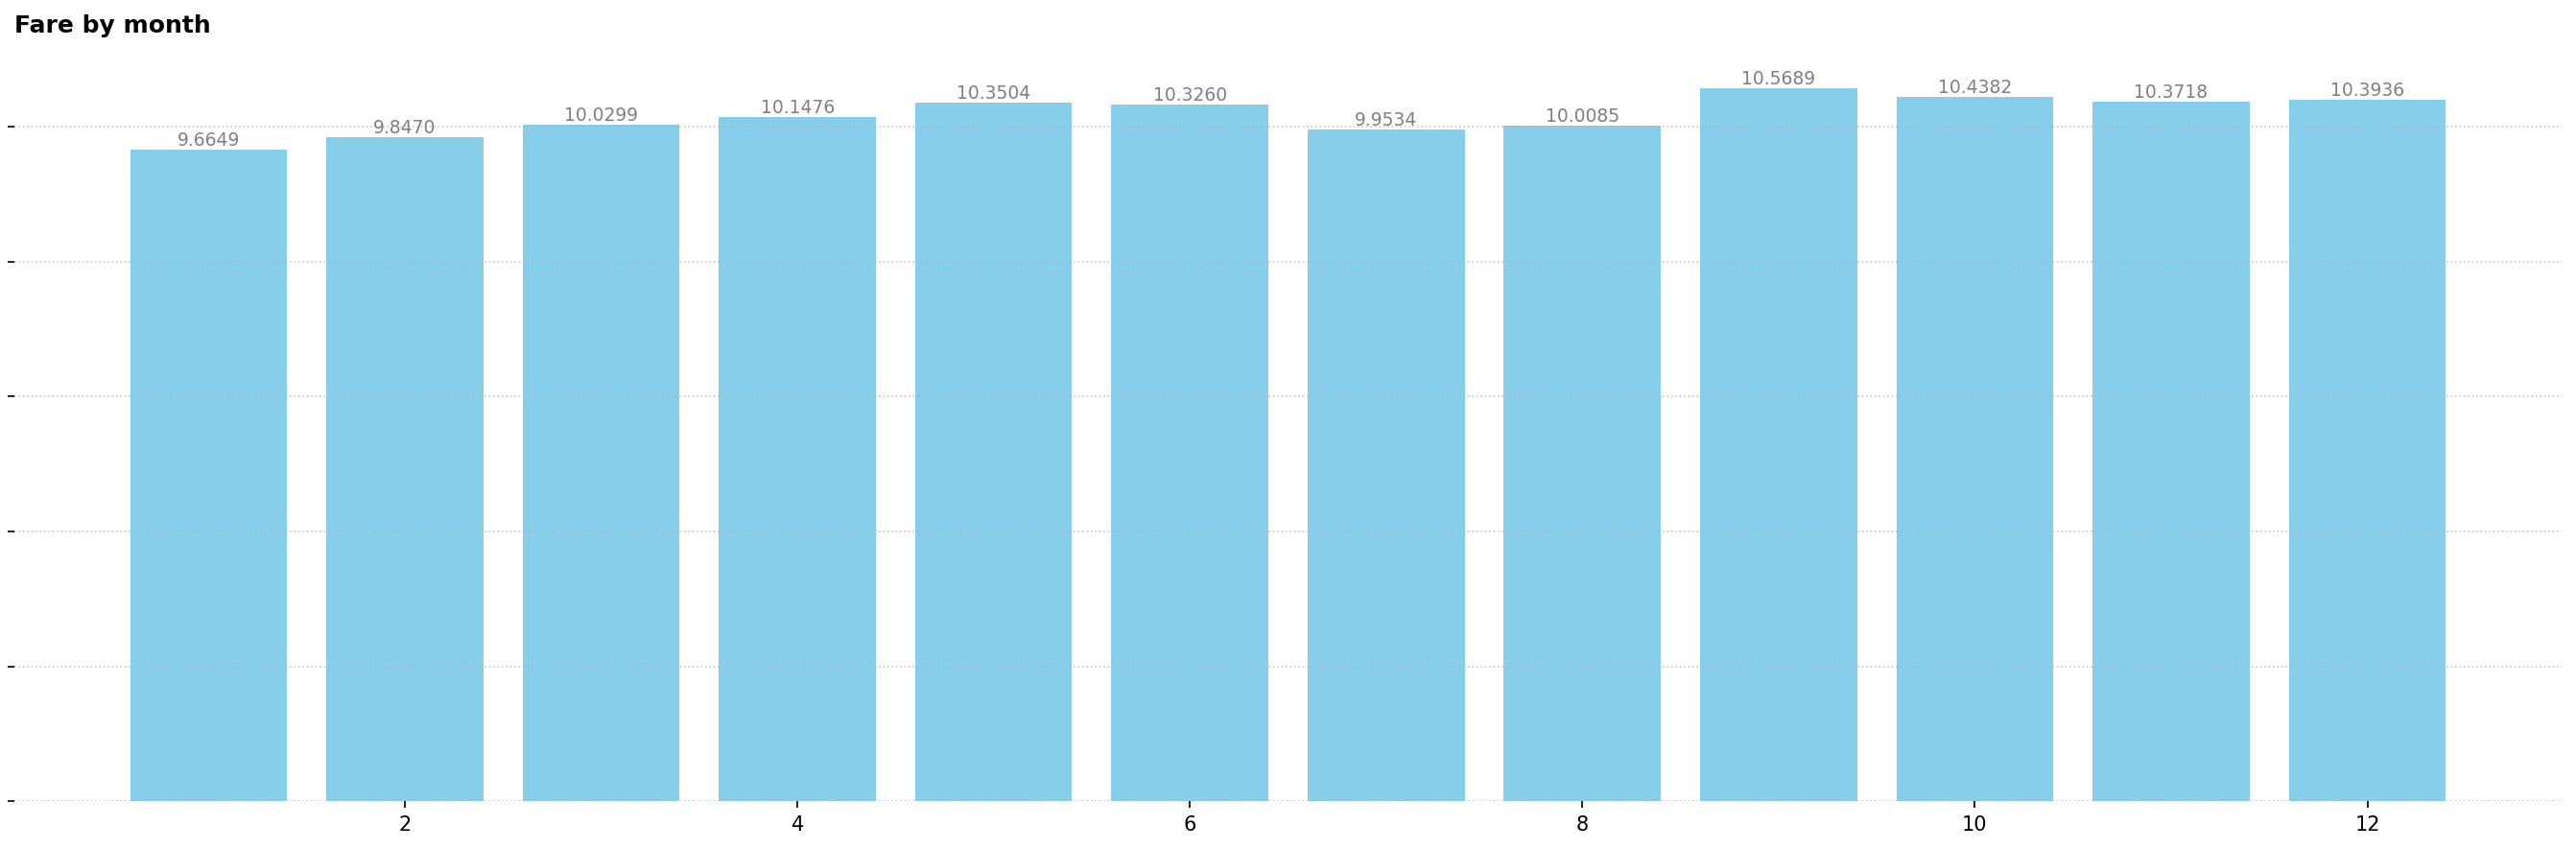

In [34]:
multiple_barplot(wide_by_month, months, "Fare by month")

The specific month seems to have little to do with the mean fare, with a slight peak in september

### Hour

In [35]:
wide_by_hour, hours = pivot_table_on_column(train.select(["hour", "fare_amount"]).collect(), "hour", "fare_amount")

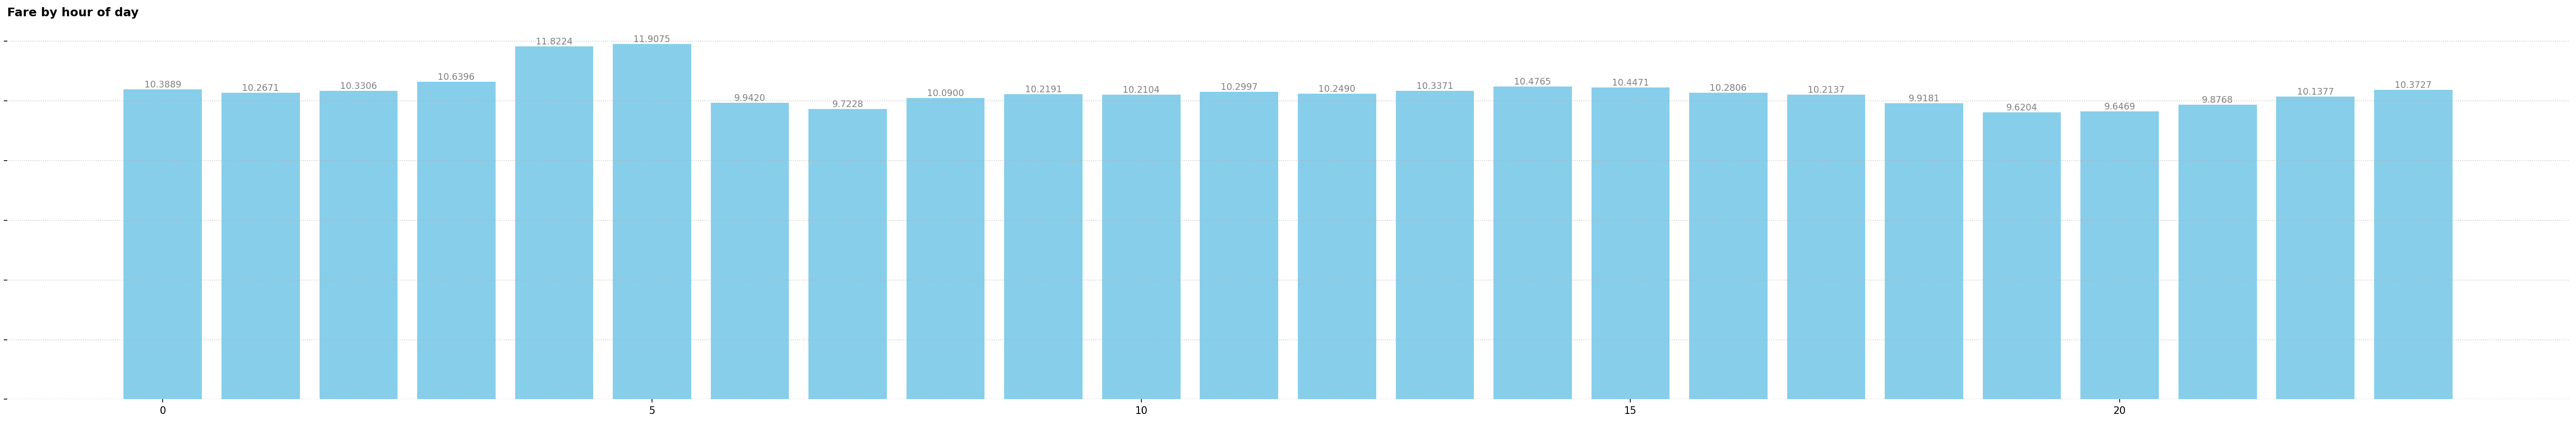

In [36]:
multiple_barplot(wide_by_hour, hours, "Fare by hour of day")

Seems that the peak mean for fare amount happens between 4 and 5 am

### Weekday

In [37]:
wide_by_weekday, weekdays = pivot_table_on_column(train.select(["day_of_week", "fare_amount"]).collect(), "day_of_week", "fare_amount")

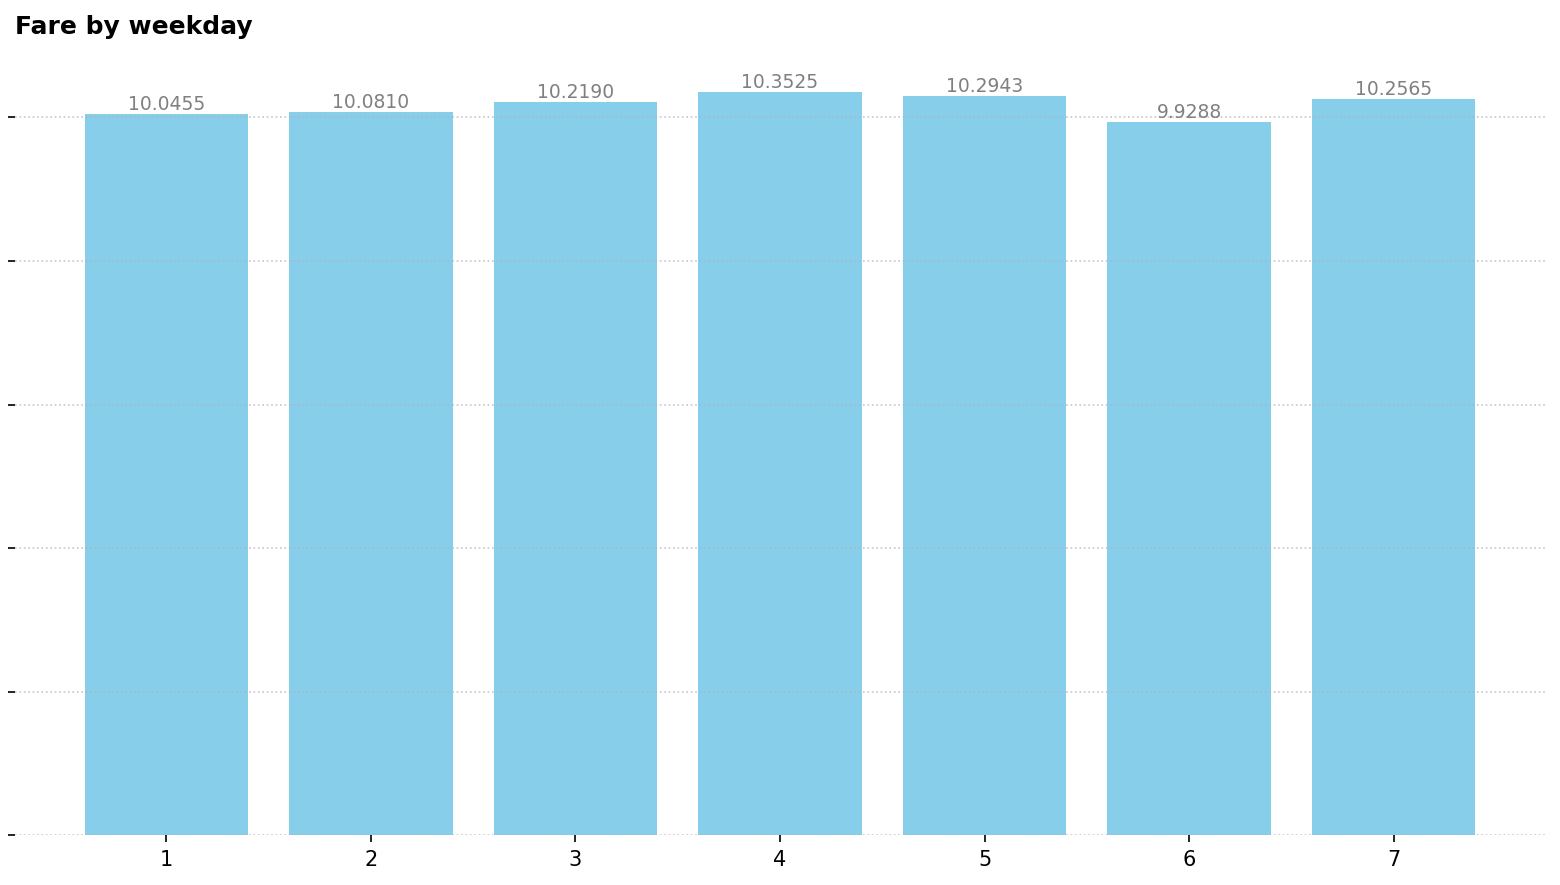

In [38]:
multiple_barplot(wide_by_weekday, weekdays, "Fare by weekday")

Thursdays have the highest mean fare, while saturdays have the lowest. Considering the work week being from monday to friday, should make sense that less rides may happen by locals on saturdays. It's interesting to note that the mean fare increases day by day from monday through thursday

## Incorporating NYC NTA

In [40]:
nta = gpd.read_file(DATA_PATH + "/nynta/nynta2020.shp").to_crs(epsg=4326)

if not os.path.exists(DATA_PATH + "/clean_df_w_nta.parquet"):
    df = train.collect().to_pandas()

    pickup_gdf = gpd.GeoDataFrame(
        df,
        geometry=[Point(xy) for xy in zip(df.pickup_longitude, df.pickup_latitude)],
        crs="EPSG:4326"
    )
    dropoff_gdf = gpd.GeoDataFrame(
        df,
        geometry=[Point(xy) for xy in zip(df.dropoff_longitude, df.dropoff_latitude)],
        crs="EPSG:4326"
    )

    pickup_joined = gpd.sjoin(pickup_gdf, nta, how="left", predicate="within")
    dropoff_joined = gpd.sjoin(dropoff_gdf, nta, how="left", predicate="within")

    df["pickup_nta"] = pickup_joined["NTAName"]
    df["dropoff_nta"] = dropoff_joined["NTAName"]

    train = pl.from_pandas(df).lazy()
    train.collect().write_parquet(DATA_PATH + "/clean_df_w_nta.parquet")
    train.head(3).collect()
else:
    train = pl.scan_parquet(DATA_PATH + "/clean_df_w_nta.parquet")

Previous operation took 1h34min

In [41]:
train.describe()

statistic,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,ride_distance,pickup_datetime_parsed,year,month,hour,day_of_week,pickup_nta,dropoff_nta
str,str,f64,str,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,str,str
"""count""","""51439929""",5.1439929e7,"""51439929""",5.1439929e7,5.1439929e7,5.1439929e7,5.1439929e7,5.1439929e7,5.1439929e7,"""51439929""",5.1439929e7,5.1439929e7,5.1439929e7,5.1439929e7,"""51309717""","""51208580"""
"""null_count""","""0""",0.0,"""0""",0.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0,0.0,0.0,0.0,"""130212""","""231349"""
"""mean""",null,10.16987,null,-73.978816,40.753039,-73.977383,40.753365,1.689366,0.037097,"""2012-03-18 15:45:34.148876""",2011.732928,6.265221,13.535469,4.03595,null,null
"""std""",null,7.155324,null,0.023849,0.022414,0.026063,0.024919,1.306355,0.032486,null,1.864993,3.43873,6.46574,1.945694,null,null
"""min""","""2009-01-01 00:00:46.0000002""",2.5,"""2009-01-01 00:00:46 UTC""",-74.25,40.68,-74.25,40.68,1.0,0.0,"""2009-01-01 00:00:46""",2009.0,1.0,0.0,1.0,"""Astoria (Central)""","""Astoria (Central)"""
"""25%""",null,6.0,null,-73.992443,40.738187,-73.9918,40.737795,1.0,0.01602,"""2010-08-12 10:03:10""",2010.0,3.0,9.0,2.0,null,null
"""50%""",null,8.1,null,-73.982286,40.754317,-73.981077,40.754717,1.0,0.027026,"""2012-03-18 16:01:05""",2012.0,6.0,14.0,4.0,null,null
"""75%""",null,12.0,null,-73.969443,40.767958,-73.967016,40.768609,2.0,0.046615,"""2013-10-18 14:00:00""",2013.0,9.0,19.0,6.0,null,null
"""max""","""2015-06-30 23:59:54.0000003""",199.7,"""2015-06-30 23:59:54 UTC""",-73.83,40.85,-73.83,40.85,6.0,0.48658,"""2015-06-30 23:59:54""",2015.0,12.0,23.0,7.0,"""Yankee Stadium-Macombs Dam Par…","""Yankee Stadium-Macombs Dam Par…"


next steps 
- visualize pickup frequency heatmap, maybe mean fare per pickup location?? visualize some expensive rides
- set conditionals for large file loading

In [42]:
train.collect().null_count()

key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,ride_distance,pickup_datetime_parsed,year,month,hour,day_of_week,pickup_nta,dropoff_nta
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0,0,130212,231349


<Axes: >

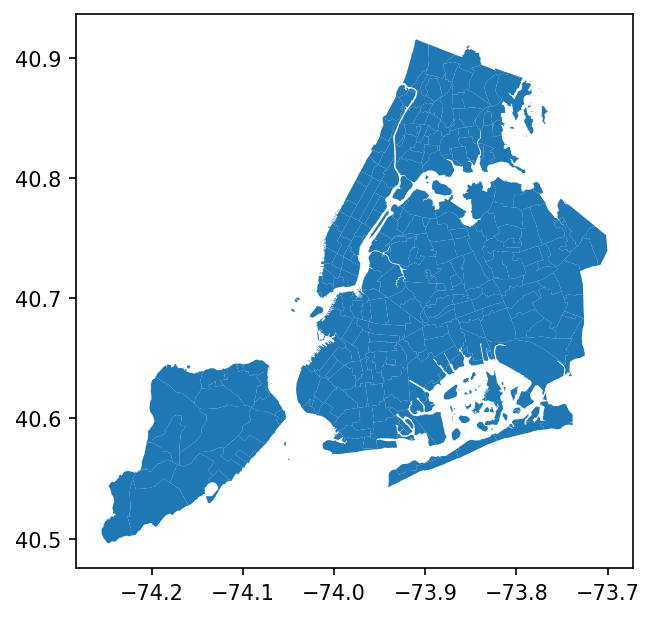

In [43]:
nta.plot()

### Plotting mean fare by dropoff NTA

In [ ]:
dropoff_fares = (
    train.select(["fare_amount", "dropoff_nta"])
    .group_by("dropoff_nta")
    .agg(pl.col("fare_amount").mean().alias("mean_fare_per_dropoff"))
    # .drop("fare_amount")
    .collect()
    .to_pandas()
)

In [65]:
nta_merged = nta.merge(dropoff_fares, how="left", left_on="NTAName", right_on="dropoff_nta").dropna(subset=["mean_fare_per_dropoff"])

boroughs = nta_merged.dissolve(by="BoroName", as_index=False)
boroughs["centroid"] = boroughs.geometry.centroid

nta_merged

/var/folders/jq/tdq0h8rj1zdbxsbs18vhfp0h0000gp/T/ipykernel_58300/434391604.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  boroughs["centroid"] = boroughs.geometry.centroid


,BoroCode,BoroName,CountyFIPS,NTA2020,NTAName,NTAAbbrev,NTAType,CDTA2020,CDTAName,Shape_Leng,Shape_Area,geometry,dropoff_nta,mean_fare
0,3,Brooklyn,047,BK0101,Greenpoint,Grnpt,0,BK01,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),28919.560811,3.532181e+07,"POLYGON ((-73.93213 40.72816, -73.93238 40.727...",Greenpoint,13.984697
1,3,Brooklyn,047,BK0102,Williamsburg,Wllmsbrg,0,BK01,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),28134.082324,2.885285e+07,"POLYGON ((-73.95814 40.7244, -73.95772 40.7242...",Williamsburg,13.697793
2,3,Brooklyn,047,BK0103,South Williamsburg,SWllmsbrg,0,BK01,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),18250.280543,1.520896e+07,"POLYGON ((-73.95024 40.70547, -73.94984 40.705...",South Williamsburg,15.013141
3,3,Brooklyn,047,BK0104,East Williamsburg,EWllmsbrg,0,BK01,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),43184.798988,5.226741e+07,"POLYGON ((-73.92406 40.71411, -73.92404 40.714...",East Williamsburg,14.227840
4,3,Brooklyn,047,BK0201,Brooklyn Heights,BkHts,0,BK02,BK02 Downtown Brooklyn-Fort Greene (CD 2 Appro...,14312.504974,9.982322e+06,"POLYGON ((-73.99236 40.68969, -73.99436 40.690...",Brooklyn Heights,14.911770
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206,4,Queens,081,QN1001,South Ozone Park,SthOznPk,0,QN10,QN10 South Ozone Park-Howard Beach (CD 10 Appr...,36690.078347,8.183659e+07,"POLYGON ((-73.80586 40.68291, -73.80561 40.682...",South Ozone Park,32.777916
207,4,Queens,081,QN1002,Ozone Park,OznPk,0,QN10,QN10 South Ozone Park-Howard Beach (CD 10 Appr...,25097.196261,2.510778e+07,"POLYGON ((-73.84013 40.68115, -73.83952 40.679...",Ozone Park,29.516742
233,4,Queens,081,QN8081,LaGuardia Airport,LGA,8,QN80,QN80 LaGuardia Airport (JIA 80 Approximation),40422.837903,3.059195e+07,"MULTIPOLYGON (((-73.87287 40.78598, -73.87283 ...",LaGuardia Airport,30.592287
234,4,Queens,081,QN8191,Flushing Meadows-Corona Park,FlshMdwCPk,9,QN81,QN81 Flushing Meadows-Corona Park (JIA 81 Appr...,61514.111128,5.520142e+07,"POLYGON ((-73.84671 40.76135, -73.84663 40.761...",Flushing Meadows-Corona Park,25.003520


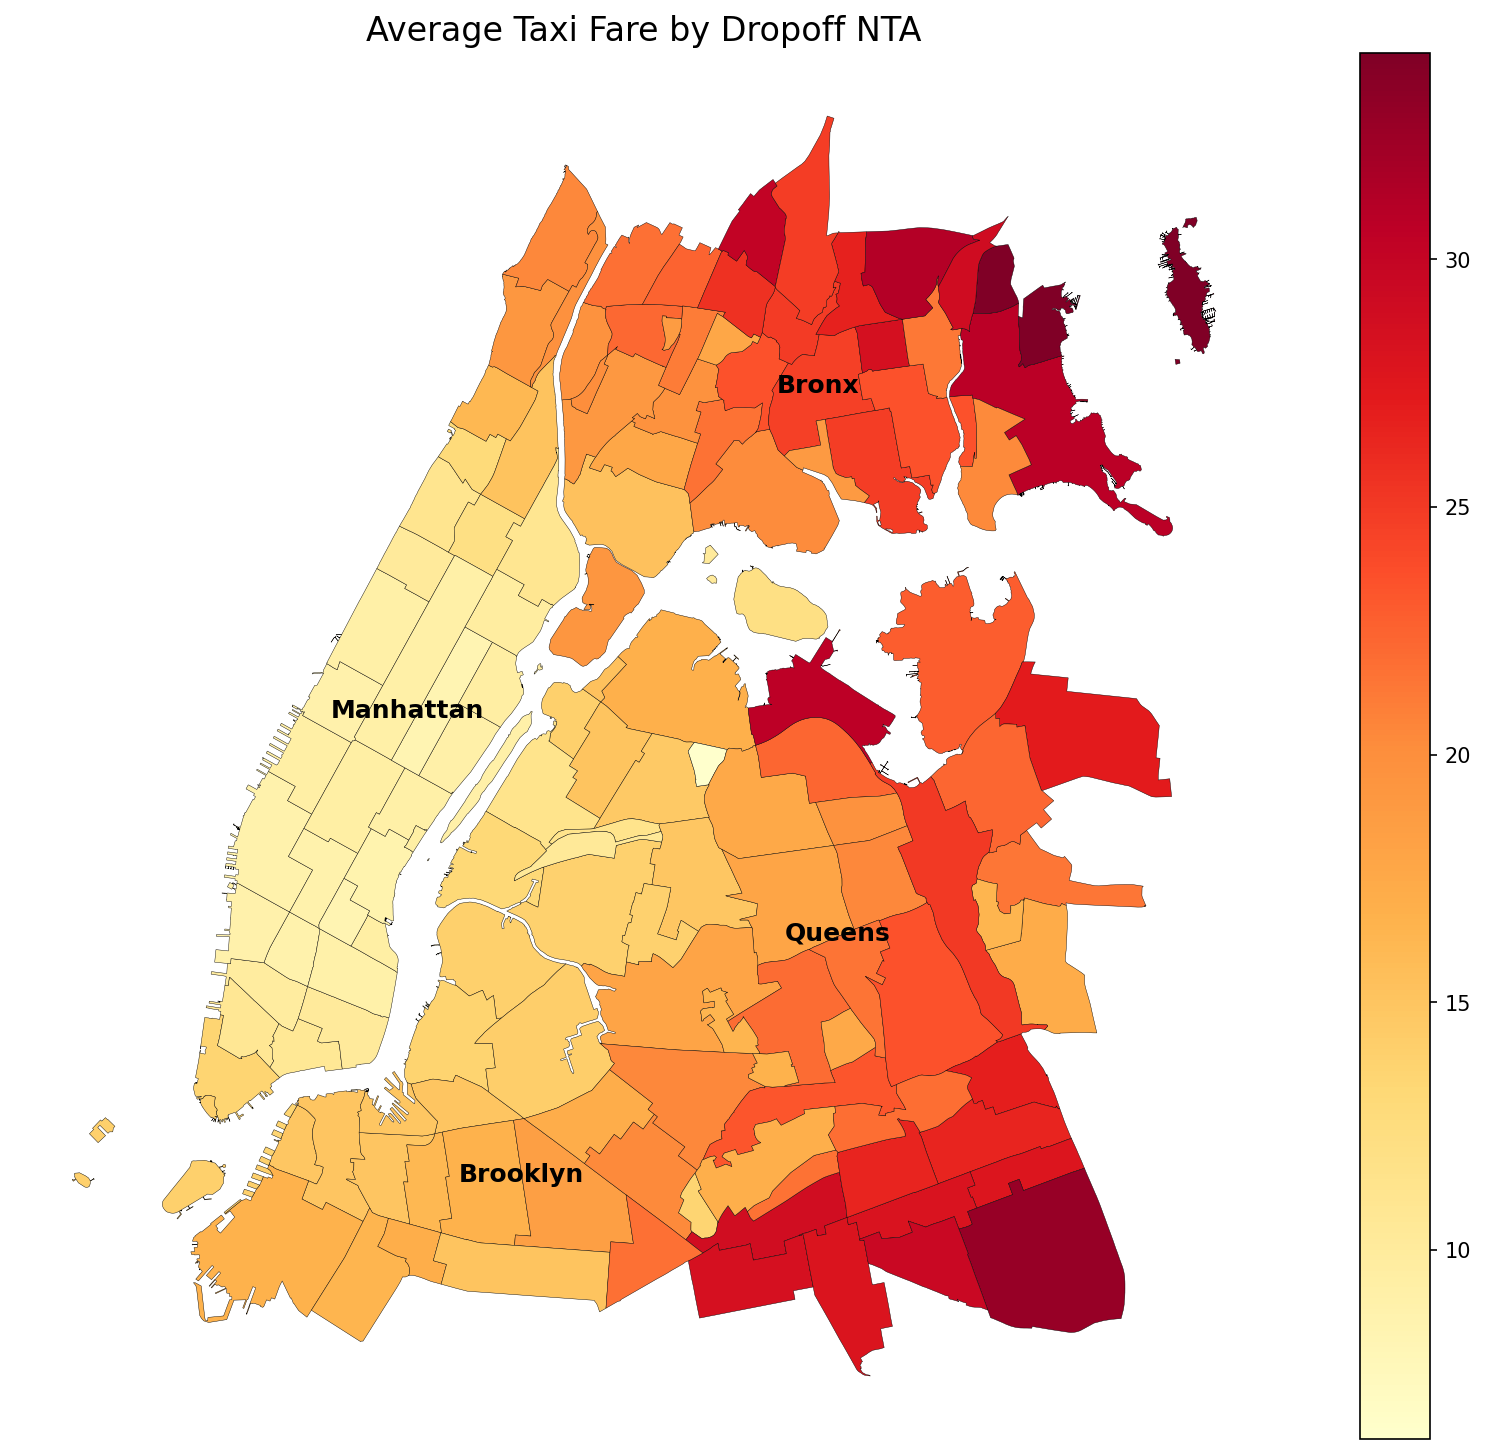

In [ ]:
fig, ax = plt.subplots(figsize=(15, 12))
nta_merged.plot(
    column="mean_fare_per_dropoff",
    cmap="YlOrRd",
    linewidth=0.2,
    edgecolor="black",
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey", "label": "No data"}
)

for _, row in boroughs.iterrows():
    x, y = row["centroid"].x, row["centroid"].y
    ax.text(x, y, row["BoroName"], fontsize=12, fontweight="bold",
            ha="center", va="center", color="black")

ax.set_title("Average Taxi Fare by Dropoff NTA", fontsize=16)
ax.axis("off")
plt.show()

It's interesting to see that the further the dropoff location is from Manhattan, the higher is the average fare. It should make sense if you consider a lot of jobs and businesses are located in Manhattan, and rides that start and end in Manhattan should cost less than commuting further away from it. Queens' and Bronx's edges, which are farther from Manhattan, are those with the highest mean dropoff fare. Mean fare per NTA might be a good indicative of fare cost.

In [67]:
train.collect_schema()

Schema([('key', String),
        ('fare_amount', Float64),
        ('pickup_datetime', String),
        ('pickup_longitude', Float64),
        ('pickup_latitude', Float64),
        ('dropoff_longitude', Float64),
        ('dropoff_latitude', Float64),
        ('passenger_count', Int64),
        ('ride_distance', Float64),
        ('pickup_datetime_parsed', Datetime(time_unit='us', time_zone=None)),
        ('year', Int32),
        ('month', Int8),
        ('hour', Int8),
        ('day_of_week', Int8),
        ('pickup_nta', String),
        ('dropoff_nta', String)])

In [71]:
dropoff_fares_pl = pl.from_pandas(dropoff_fares).lazy()

train = train.join(dropoff_fares_pl, on="dropoff_nta", how="left")
train.collect_schema()

Schema([('key', String),
        ('fare_amount', Float64),
        ('pickup_datetime', String),
        ('pickup_longitude', Float64),
        ('pickup_latitude', Float64),
        ('dropoff_longitude', Float64),
        ('dropoff_latitude', Float64),
        ('passenger_count', Int64),
        ('ride_distance', Float64),
        ('pickup_datetime_parsed', Datetime(time_unit='us', time_zone=None)),
        ('year', Int32),
        ('month', Int8),
        ('hour', Int8),
        ('day_of_week', Int8),
        ('pickup_nta', String),
        ('dropoff_nta', String),
        ('mean_fare', Float64)])

In [72]:
train.head(5).collect()

key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,ride_distance,pickup_datetime_parsed,year,month,hour,day_of_week,pickup_nta,dropoff_nta,mean_fare
str,f64,str,f64,f64,f64,f64,i64,f64,datetime[μs],i32,i8,i8,i8,str,str,f64
"""2009-06-15 17:26:21.0000001""",4.5,"""2009-06-15 17:26:21 UTC""",-73.844311,40.721319,-73.84161,40.712278,1,0.011742,2009-06-15 17:26:21,2009,6,17,1,"""Forest Hills""","""Forest Hills""",23.505785
"""2010-01-05 16:52:16.0000002""",16.9,"""2010-01-05 16:52:16 UTC""",-74.016048,40.711303,-73.979268,40.782004,1,0.107481,2010-01-05 16:52:16,2010,1,16,2,"""Financial District-Battery Par…","""Upper West Side (Central)""",9.183994
"""2011-08-18 00:35:00.00000049""",5.7,"""2011-08-18 00:35:00 UTC""",-73.982738,40.76127,-73.991242,40.750562,2,0.019212,2011-08-18 00:35:00,2011,8,0,4,"""Midtown-Times Square""","""Midtown South-Flatiron-Union S…",8.733747
"""2012-04-21 04:30:42.0000001""",7.7,"""2012-04-21 04:30:42 UTC""",-73.98713,40.733143,-73.991567,40.758092,1,0.029386,2012-04-21 04:30:42,2012,4,4,6,"""East Village""","""Hell's Kitchen""",9.295563
"""2010-03-09 07:51:00.000000135""",5.3,"""2010-03-09 07:51:00 UTC""",-73.968095,40.768008,-73.956655,40.783762,1,0.027194,2010-03-09 07:51:00,2010,3,7,2,"""Upper East Side-Carnegie Hill""","""Upper East Side-Carnegie Hill""",8.329465


### Plotting frequency of pickup location

In [78]:
pickup_count = (
    train.select(["fare_amount", "pickup_nta"])
    .group_by("pickup_nta")
    .agg(pl.col("pickup_nta").count().alias("pickup_count"))
    # .drop("fare_amount")
    .collect()
    .to_pandas()
)

nta_merged_pickup_count = nta.merge(pickup_count, how="left", left_on="NTAName", right_on="pickup_nta").dropna(subset=["pickup_nta"])

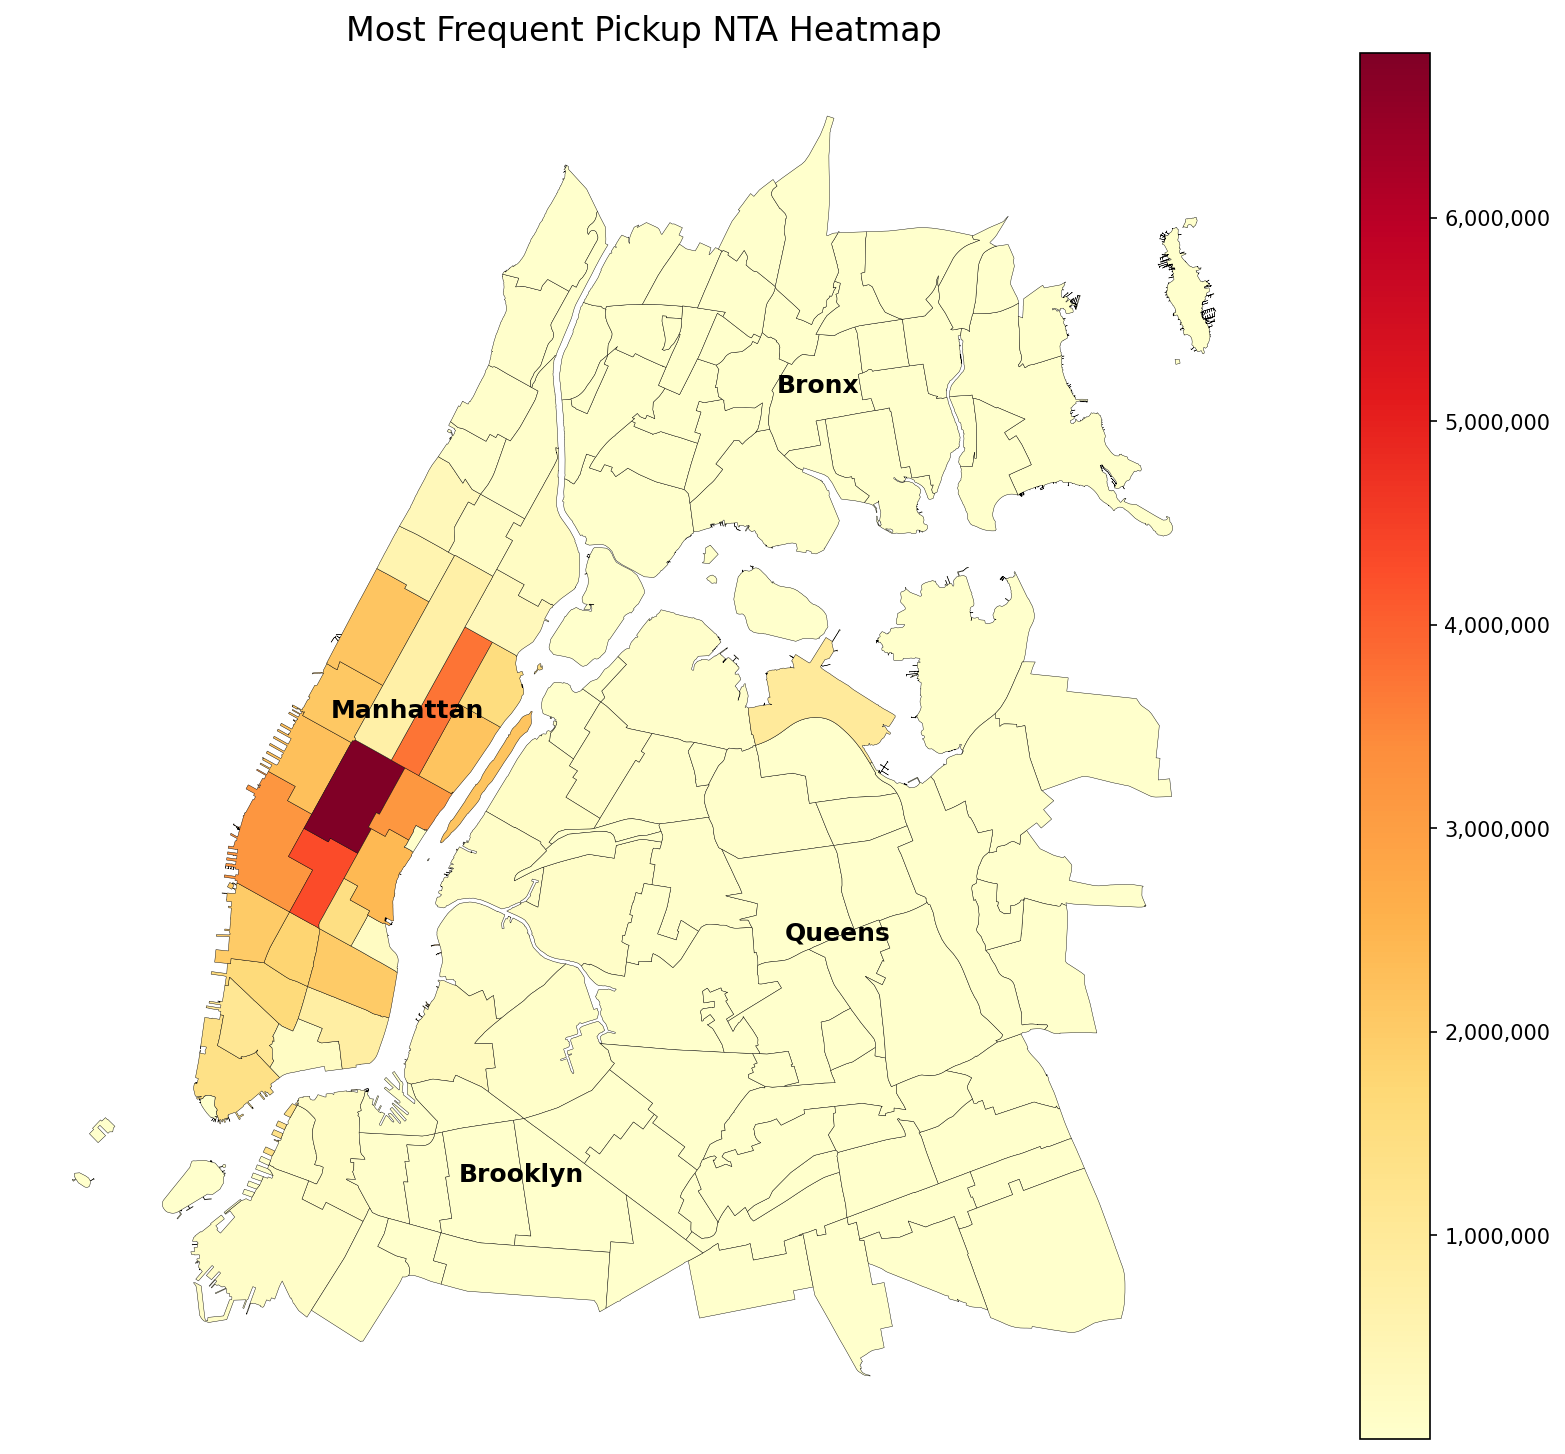

In [ ]:
fig, ax = plt.subplots(figsize=(15, 12))
gdf_plot = nta_merged_pickup_count.plot(
    column="pickup_count",
    cmap="YlOrRd",
    linewidth=0.2,
    edgecolor="black",
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey", "label": "No data"}
)

for _, row in boroughs.iterrows():
    x, y = row["centroid"].x, row["centroid"].y
    ax.text(x, y, row["BoroName"], fontsize=12, fontweight="bold",
            ha="center", va="center", color="black")
    
cb = gdf_plot.get_figure().get_axes()[1]

formatter = FuncFormatter(lambda x, _: f"{int(x):,}")
cb.yaxis.set_major_formatter(formatter)

ax.set_title("Most Frequent Pickup NTA Heatmap", fontsize=16)
ax.axis("off")
plt.show()

Central to lower Manhattan has by far the highest count of pickup frequency, considering that's where most businesses are located

In [83]:
dropoff_count = (
    train.select(["fare_amount", "dropoff_nta"])
    .group_by("dropoff_nta")
    .agg(pl.col("dropoff_nta").count().alias("dropoff_count"))
    .collect()
    .to_pandas()
)

nta_merged_dropoff_count = nta.merge(dropoff_count, how="left", left_on="NTAName", right_on="dropoff_nta").dropna(subset=["dropoff_nta"])

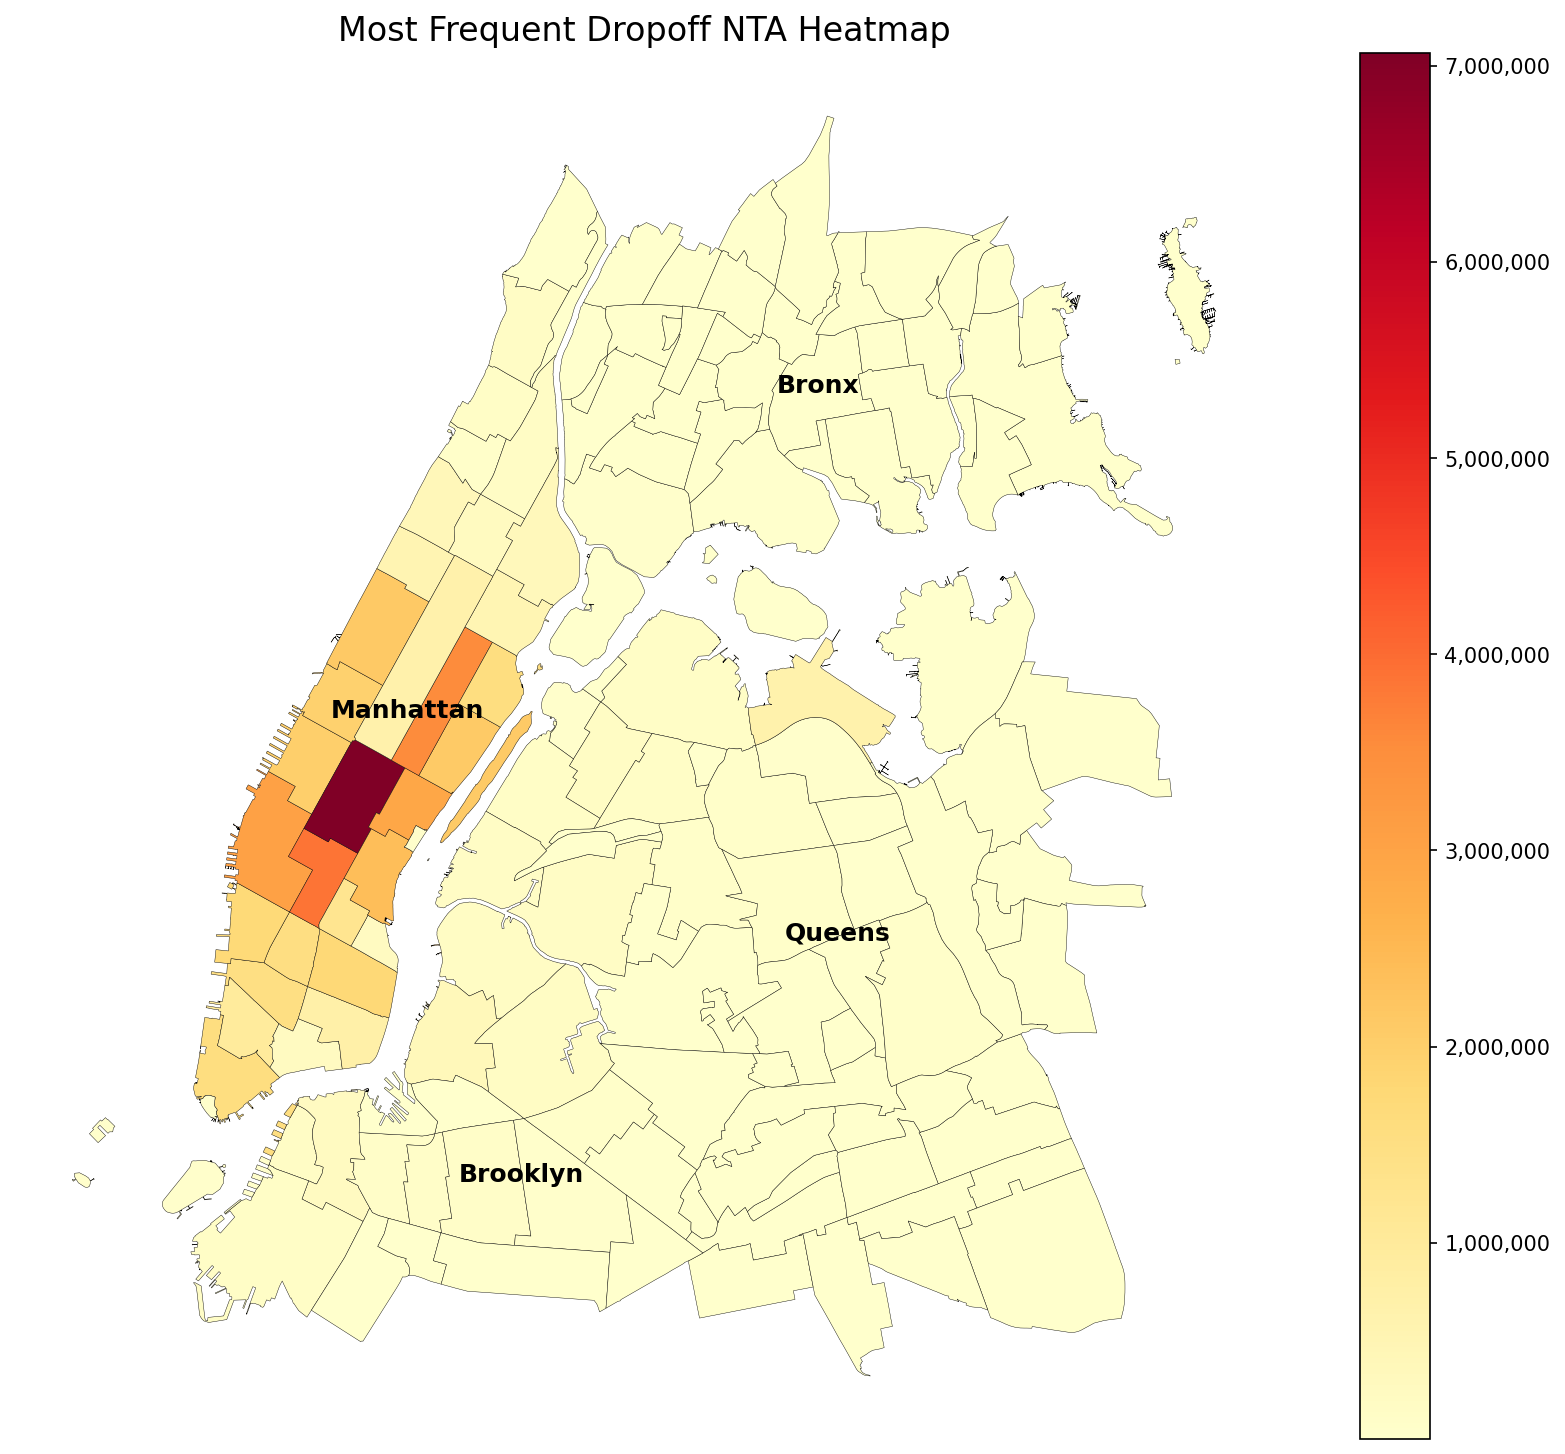

In [ ]:
fig, ax = plt.subplots(figsize=(15, 12))
gdf_plot = nta_merged_dropoff_count.plot(
    column="dropoff_count",
    cmap="YlOrRd",
    linewidth=0.2,
    edgecolor="black",
    legend=True,
    ax=ax,
    missing_kwds={"color": "lightgrey", "label": "No data"}
)

for _, row in boroughs.iterrows():
    x, y = row["centroid"].x, row["centroid"].y
    ax.text(x, y, row["BoroName"], fontsize=12, fontweight="bold",
            ha="center", va="center", color="black")
    
cb = gdf_plot.get_figure().get_axes()[1]

formatter = FuncFormatter(lambda x, _: f"{int(x):,}")
cb.yaxis.set_major_formatter(formatter)

ax.set_title("Most Frequent Dropoff NTA Heatmap", fontsize=16)
ax.axis("off")
plt.show()

The same is true for dropoff locations, mid to south manhattan is the most common destination. Recall from the mean fare heatmap that it's one of the lowest mean fares too. Considering most pickups and dropoffs occurr on the same regions, it's easy to think that most rides are short rides between those areas

In [86]:
train.collect_schema()

Schema([('key', String),
        ('fare_amount', Float64),
        ('pickup_datetime', String),
        ('pickup_longitude', Float64),
        ('pickup_latitude', Float64),
        ('dropoff_longitude', Float64),
        ('dropoff_latitude', Float64),
        ('passenger_count', Int64),
        ('ride_distance', Float64),
        ('pickup_datetime_parsed', Datetime(time_unit='us', time_zone=None)),
        ('year', Int32),
        ('month', Int8),
        ('hour', Int8),
        ('day_of_week', Int8),
        ('pickup_nta', String),
        ('dropoff_nta', String),
        ('mean_fare', Float64)])

### Most Frequent Routes

In [102]:
route_stats = (
    train.group_by(["pickup_nta", "dropoff_nta"])
      .agg([
          pl.count().alias("trip_count"),
          pl.col("fare_amount").mean().alias("mean_fare_per_dropoff")
      ])
      .sort("trip_count", descending=True)
)

top_routes = route_stats.head(15)


/var/folders/jq/tdq0h8rj1zdbxsbs18vhfp0h0000gp/T/ipykernel_58300/1161434910.py:4: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
  pl.count().alias("trip_count"),


/var/folders/jq/tdq0h8rj1zdbxsbs18vhfp0h0000gp/T/ipykernel_58300/3857703406.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  nta["centroid"] = nta.geometry.centroid


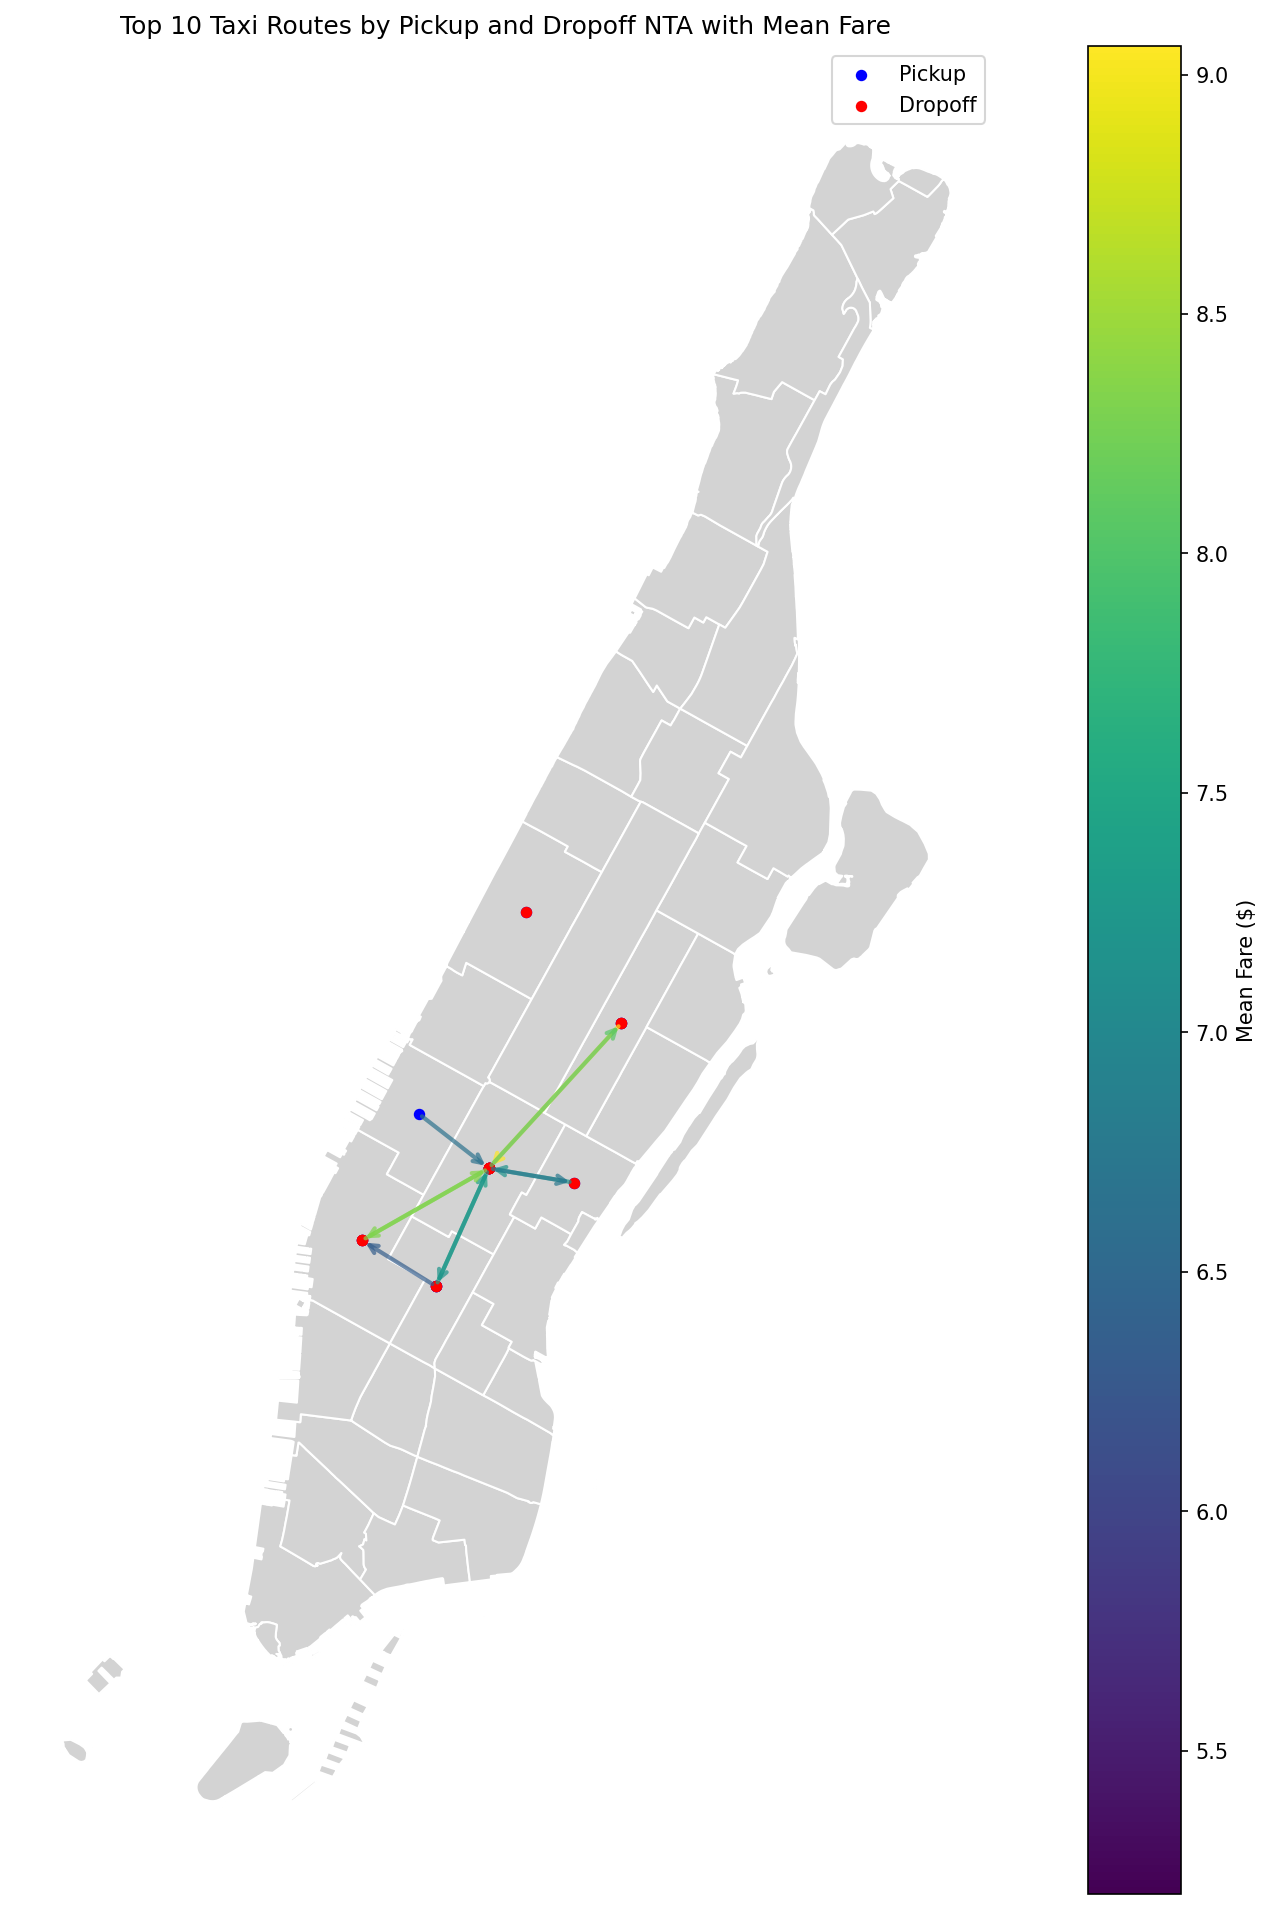

In [103]:
nta["centroid"] = nta.geometry.centroid

# Convert centroids to a DataFrame for easy merging
nta_points = nta[["NTAName", "centroid"]].set_index("NTAName")

top_routes_pd = top_routes.collect().to_pandas()

# Merge pickup centroids
top_routes_pd = gpd.GeoDataFrame(top_routes_pd.merge(
    nta_points, left_on="pickup_nta", right_index=True, how="left"
).rename(columns={"centroid": "pickup_point"}))

# Merge dropoff centroids
top_routes_pd = gpd.GeoDataFrame(top_routes_pd.merge(
    nta_points, left_on="dropoff_nta", right_index=True, how="left"
).rename(columns={"centroid": "dropoff_point"}))

top_routes_pd

fig, ax = plt.subplots(figsize=(16, 16))

# Plot all NTA polygons lightly as background
nta[nta["BoroName"] == "Manhattan"].plot(ax=ax, color="lightgrey", edgecolor="white")

# Plot pickup and dropoff points (optional)
top_routes_pd["pickup_point"].plot(ax=ax, color="blue", markersize=20, label="Pickup")
top_routes_pd["dropoff_point"].plot(ax=ax, color="red", markersize=20, label="Dropoff")

# Normalize mean_fare for line colors
mean_fares = top_routes_pd["mean_fare_per_dropoff"]
norm = plt.Normalize(mean_fares.min(), mean_fares.max())
cmap = plt.cm.viridis

# Draw arrows between points
for _, row in top_routes_pd.iterrows():
    start = (row["pickup_point"].x, row["pickup_point"].y)
    end = (row["dropoff_point"].x, row["dropoff_point"].y)
    color = cmap(norm(row["mean_fare_per_dropoff"]))

    ax.annotate(
        "",
        xy=end,
        xytext=start,
        arrowprops=dict(arrowstyle="->", color=color, lw=2, alpha=0.7),
    )

# Colorbar for mean fare
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Mean Fare ($)")

ax.set_title("Top 10 Taxi Routes by Pickup and Dropoff NTA with Mean Fare")
ax.axis("off")
plt.legend()
plt.show()

All the top 10 rroutes occurr within Manhattan mid to south regions, with the highest mean fare just below $10. It may be a good idea to include a new Route feature and embed it before feeding to the NN

In [104]:
train.collect_schema()

Schema([('key', String),
        ('fare_amount', Float64),
        ('pickup_datetime', String),
        ('pickup_longitude', Float64),
        ('pickup_latitude', Float64),
        ('dropoff_longitude', Float64),
        ('dropoff_latitude', Float64),
        ('passenger_count', Int64),
        ('ride_distance', Float64),
        ('pickup_datetime_parsed', Datetime(time_unit='us', time_zone=None)),
        ('year', Int32),
        ('month', Int8),
        ('hour', Int8),
        ('day_of_week', Int8),
        ('pickup_nta', String),
        ('dropoff_nta', String),
        ('mean_fare', Float64)])

In [106]:
train = train.with_columns(pl.col("mean_fare").alias("mean_fare_per_dropoff")).drop("mean_fare")
train.collect_schema()

Schema([('key', String),
        ('fare_amount', Float64),
        ('pickup_datetime', String),
        ('pickup_longitude', Float64),
        ('pickup_latitude', Float64),
        ('dropoff_longitude', Float64),
        ('dropoff_latitude', Float64),
        ('passenger_count', Int64),
        ('ride_distance', Float64),
        ('pickup_datetime_parsed', Datetime(time_unit='us', time_zone=None)),
        ('year', Int32),
        ('month', Int8),
        ('hour', Int8),
        ('day_of_week', Int8),
        ('pickup_nta', String),
        ('dropoff_nta', String),
        ('mean_fare_per_dropoff', Float64)])

In [ ]:
train.collect().write_parquet(DATA_PATH + "/final_eda_df.parquet")

: 